In [1]:
from collections import Counter
from itertools import combinations
import os
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np
import pandas as pd
import seaborn as sns
from sklearn.linear_model import LinearRegression
from datetime import datetime
from Bio import SeqIO
from Bio.Seq import Seq

from Bio import SeqIO, Phylo
from Bio.SeqRecord import SeqRecord
import subprocess
import re

from Levenshtein import distance as lev_distance 

from dnsmex.local import localify
from netam.sequences import translate_sequence, AA_STR_SORTED
from utils import sort_antibody_sites


figures_dir = localify("FIGURES_DIR")

### Create IMGT and Chothia reference files
Create germline codon tables for IMGT and Chothia numbering schemes.

This script downloads OGRDB germline sequences and creates codon-level dataframes
with site numbering for both IMGT and Chothia schemes.

Purpose:

We need germline annotation files for:
- In current analysis repo:
    - Add germline annotation per site (is_germline_codon/aa)
    - Annotate sites for out of frame data - ANARCI cannot be used to number these
      sequences, so for the V gene area (until CDR3) for sequences that have no
      frameshifts (filtered for earlier), we can use the germline annotation files
      to annotate the sequences according to PARTIS v gene identification
- Later this can be used for pcp generation files (pcp-pipeline) with Chothia-based
  CDRs start and end sites.

Approach:

IMGT gapped files can be downloaded from the OGRDB website.
There is no such resource for Chothia.
We create Chothia numbering with ANARCI:
- Download the ungapped version from OGRDB website
- Filter for IGHV
- Run in ANARCI with human and heavy chain parameters
- Note: Chothia uses insertion codes (e.g., 52A, 52B) while IMGT is just int-based
  for IGHV gene area

Output files:

- germline/germline_codons_imgt.csv: IMGT numbering scheme
- germline/germline_codons_chothia.csv: Chothia numbering scheme


For this analysis, we use the OGRDB reference files. 
The reference files used by partis also come from this dataset, so the two are directly comparable. The key difference is that we download the gapped version of the OGRDB references, because the gaps preserve IMGT numbering. We also compared the gene IDs and they are the same. Thus we can use the OGRDB reference to annotate the files classified by partis.

In this analysis
- We create reference files that we can later merge onto sitewise dataframes to add gemrline annotations per v gene.
- We calculate the similarities between the different v genes and plot that.

In [2]:
#numbering_scheme = 'imgt'
numbering_scheme = 'chothia'
codons_df = pd.read_csv(localify(f"germline/germline_codons_{numbering_scheme}.csv"), dtype={'site': str} )

In [3]:
codons_df

,site,codon,v_gene,v_family,amino_acid
0,1,CAG,IGHV1-18*01,IGHV1,Q
1,2,GTT,IGHV1-18*01,IGHV1,V
2,3,CAG,IGHV1-18*01,IGHV1,Q
3,4,CTG,IGHV1-18*01,IGHV1,L
4,5,GTG,IGHV1-18*01,IGHV1,V
...,...,...,...,...,...
18535,90,TAT,IGHV7-81*01,IGHV7,Y
18536,91,TAC,IGHV7-81*01,IGHV7,Y
18537,92,TGT,IGHV7-81*01,IGHV7,C
18538,93,GCG,IGHV7-81*01,IGHV7,A


In [4]:
## create the germline codon tables for IMGT and Chothia schemes
! cd /home/nharel/re/dasm-epistasis-experiments && source ~/.bashrc && conda activate netam_env && python create_germline_codon_tables.py

LIBCIFPP_DATA_DIR has been unset


LIBCIFPP_DATA_DIR has been set to: /home/nharel/miniforge3/envs/netam_env/share/libcifpp


Creating Germline Codon Tables

### Step 1: Downloading OGRDB files ###
Gapped FASTA file germline/ogrdb_human_IGH_gapped.fasta already exists. Skipping download.
Ungapped FASTA file germline/ogrdb_human_IGH_ungapped.fasta already exists. Skipping download.

### Step 2: Creating IMGT codon table ###

=== Creating IMGT codon table ===
Verifying that gaps are codon-aligned...


✓ All gaps are codon-aligned (3 nucleotides per codon)
Loaded 198 IGHV sequences


Removing 6 genes with stop codons


IMGT codon table saved: germline/germline_codons_imgt.csv
  Rows: 18857
  Unique genes: 192

### Step 3: Preparing files for Chothia numbering ###
Filtering IGHV sequences from germline/ogrdb_human_IGH_ungapped.fasta...


Filtered 198 IGHV sequences saved to germline/ogrdb_human_IGH_ungapped_ighv.fasta
Translating sequences to amino acids...
Translated 198 sequences saved to germline/ogrdb_human_IGH_ungapped_ighv_aa.fasta

### Step 4: Running ANARCI with Chothia numbering ###

Running ANARCI with chothia numbering...


ANARCI completed successfully! Output: germline/ogrdb_human_IGH_ungapped_ighv_chothia_H.csv

### Step 5: Creating Chothia codon table ###

=== Creating Chothia codon table ===
Loaded ANARCI results: 198 sequences


Created dataframe with 19397 rows from 198 sequences
Removing 4 genes with stop codons
Removing 5 genes not extending to site 94


Chothia codon table saved: germline/germline_codons_chothia.csv
  Rows: 18540
  Unique genes: 189

SUMMARY
IMGT codon table:
  File: germline/germline_codons_imgt.csv
  Genes: 192
  Rows: 18857

Chothia codon table:
  File: germline/germline_codons_chothia.csv
  Genes: 189
  Rows: 18540

Done!


In [5]:
# test simialrities and differences between IMGT and Chothia germline codon tables

# Load both germline codon tables
imgt_codons = pd.read_csv(localify(f"germline/germline_codons_imgt.csv"))
chothia_codons = pd.read_csv(localify(f"germline/germline_codons_chothia.csv"))

print("=" * 80)
print("IMGT vs Chothia Germline Codon Tables Comparison")
print("=" * 80)

# Test 1: Basic statistics
print("\n=== Test 1: Basic Statistics ===")
print(f"IMGT table:")
print(f"  Rows: {len(imgt_codons):,}")
print(f"  Unique genes: {imgt_codons['v_gene'].nunique()}")
print(f"  Unique sites: {imgt_codons['site'].nunique()}")
print(f"  Site range: {imgt_codons['site'].min()} - {imgt_codons['site'].max()}")

print(f"\nChothia table:")
print(f"  Rows: {len(chothia_codons):,}")
print(f"  Unique genes: {chothia_codons['v_gene'].nunique()}")
print(f"  Unique sites: {chothia_codons['site'].nunique()}")
print(f"  Site range: {chothia_codons['site'].min()} - {chothia_codons['site'].max()}")

# Test 2: Gene overlap
print("\n=== Test 2: Gene Overlap ===")
imgt_genes = set(imgt_codons['v_gene'].unique())
chothia_genes = set(chothia_codons['v_gene'].unique())

genes_in_both = imgt_genes & chothia_genes
genes_only_imgt = imgt_genes - chothia_genes
genes_only_chothia = chothia_genes - imgt_genes

print(f"Genes in both schemes: {len(genes_in_both)}")
print(f"Genes only in IMGT: {len(genes_only_imgt)}")
if genes_only_imgt:
    print(f"  Examples: {list(genes_only_imgt)[:5]}")
print(f"Genes only in Chothia: {len(genes_only_chothia)}")
if genes_only_chothia:
    print(f"  Examples: {list(genes_only_chothia)[:5]}")

# Test 3: Site numbering differences
print("\n=== Test 3: Site Numbering Schemes ===")
print(f"IMGT sites (first 20): {sorted(imgt_codons['site'].unique())[:20]}")
print(f"Chothia sites (first 20): {sorted(chothia_codons['site'].unique())[:20]}")

# Check if Chothia has insertion codes (like 52A, 52B)
chothia_sites_with_letters = [s for s in chothia_codons['site'].unique() if any(c.isalpha() for c in str(s))]
print(f"\nChothia sites with insertion codes: {len(chothia_sites_with_letters)}")
if chothia_sites_with_letters:
    print(f"  Examples: {sorted(chothia_sites_with_letters)[:10]}")

# Test 4: Sequence alignment for shared genes
print("\n=== Test 4: Sequence Comparison for Shared Genes ===")

# Pick a gene that exists in both schemes
test_gene = list(genes_in_both)[0]
print(f"Testing with gene: {test_gene}")

imgt_gene_data = imgt_codons[imgt_codons['v_gene'] == test_gene].sort_values('site')
chothia_gene_data = chothia_codons[chothia_codons['v_gene'] == test_gene].sort_values('site')

print(f"\nIMGT sites for {test_gene}: {len(imgt_gene_data)} positions")
print(f"Chothia sites for {test_gene}: {len(chothia_gene_data)} positions")

# Compare sequences (should be identical, just numbered differently)
imgt_seq = ''.join(imgt_gene_data['amino_acid'].values)
chothia_seq = ''.join(chothia_gene_data['amino_acid'].values)

print(f"\nIMGT sequence length: {len(imgt_seq)} aa")
print(f"Chothia sequence length: {len(chothia_seq)} aa")

# Compare the overlap
min_len = min(len(imgt_seq), len(chothia_seq))
if min_len > 0:
    matches = sum(1 for i in range(min_len) if imgt_seq[i] == chothia_seq[i])
    print(f"Sequence identity (first {min_len} positions): {matches/min_len*100:.1f}%")

# Test 5: Position counts per gene
print("\n=== Test 5: Position Counts Per Gene ===")

imgt_positions_per_gene = imgt_codons.groupby('v_gene')['site'].count()
chothia_positions_per_gene = chothia_codons.groupby('v_gene')['site'].count()

print(f"IMGT - Average positions per gene: {imgt_positions_per_gene.mean():.1f}")
print(f"Chothia - Average positions per gene: {chothia_positions_per_gene.mean():.1f}")

# For shared genes, compare position counts
shared_gene_comparison = pd.DataFrame({
    'imgt_positions': imgt_positions_per_gene,
    'chothia_positions': chothia_positions_per_gene
}).dropna()

print(f"\nFor {len(shared_gene_comparison)} shared genes:")
print(f"  Average IMGT positions: {shared_gene_comparison['imgt_positions'].mean():.1f}")
print(f"  Average Chothia positions: {shared_gene_comparison['chothia_positions'].mean():.1f}")
print(f"  Genes with different position counts: {(shared_gene_comparison['imgt_positions'] != shared_gene_comparison['chothia_positions']).sum()}")

# Show some examples of genes with different position counts
different_counts = shared_gene_comparison[shared_gene_comparison['imgt_positions'] != shared_gene_comparison['chothia_positions']]
if len(different_counts) > 0:
    print(f"\nExamples of genes with different position counts:")
    print(different_counts.head(10))

# Test 6: Amino acid and codon distributions
print("\n=== Test 6: Amino Acid and Codon Distributions ===")

imgt_aa_counts = imgt_codons['amino_acid'].value_counts()
chothia_aa_counts = chothia_codons['amino_acid'].value_counts()

print(f"IMGT - Most common amino acids:")
print(imgt_aa_counts.head(5))

print(f"\nChothia - Most common amino acids:")
print(chothia_aa_counts.head(5))

# Test 7: V family distribution
print("\n=== Test 7: V Family Distribution ===")

imgt_family_counts = imgt_codons.groupby('v_family')['v_gene'].nunique()
chothia_family_counts = chothia_codons.groupby('v_family')['v_gene'].nunique()

print(f"IMGT families:")
print(imgt_family_counts.sort_index())

print(f"\nChothia families:")
print(chothia_family_counts.sort_index())

print("\n" + "=" * 80)
print("Summary:")
print("- Both tables cover overlapping but not identical gene sets")
print("- IMGT uses integer numbering, Chothia uses insertion codes (e.g., 52A)")
print("- Chothia sequences end at position 94 (end of V domain)")
print("- IMGT sequences extend further into CDR3/junction region")
print("=" * 80)

IMGT vs Chothia Germline Codon Tables Comparison

=== Test 1: Basic Statistics ===
IMGT table:
  Rows: 18,857
  Unique genes: 192
  Unique sites: 103
  Site range: 1 - 107

Chothia table:
  Rows: 18,540
  Unique genes: 189
  Unique sites: 102
  Site range: 1 - 94

=== Test 2: Gene Overlap ===
Genes in both schemes: 189
Genes only in IMGT: 3
  Examples: ['IGHV8-51-1*05', 'IGHV8-51-1*04', 'IGHV8-51-1*02']
Genes only in Chothia: 0

=== Test 3: Site Numbering Schemes ===
IMGT sites (first 20): [np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5), np.int64(6), np.int64(7), np.int64(8), np.int64(9), np.int64(11), np.int64(12), np.int64(13), np.int64(14), np.int64(15), np.int64(16), np.int64(17), np.int64(18), np.int64(19), np.int64(20), np.int64(21)]
Chothia sites (first 20): ['1', '10', '11', '12', '13', '14', '15', '16', '17', '18', '19', '2', '20', '21', '22', '23', '24', '25', '26', '27']

Chothia sites with insertion codes: 8
  Examples: ['31A', '31B', '52A', '52B', '52C', '

IMGT families:
v_family
IGHV1    41
IGHV2    11
IGHV3    85
IGHV4    40
IGHV5     6
IGHV6     1
IGHV7     5
IGHV8     3
Name: v_gene, dtype: int64

Chothia families:
v_family
IGHV1    41
IGHV2    11
IGHV3    85
IGHV4    40
IGHV5     6
IGHV6     1
IGHV7     5
Name: v_gene, dtype: int64

Summary:
- Both tables cover overlapping but not identical gene sets
- IMGT uses integer numbering, Chothia uses insertion codes (e.g., 52A)
- Chothia sequences end at position 94 (end of V domain)
- IMGT sequences extend further into CDR3/junction region


In [6]:
# calculate distance between v genes

def calculate_similarity(df, level="nucleotide", metric="hamming"):
    """
    Calculate pairwise similarity between v_genes using nucleotides or amino acids,
    with Hamming or Levenshtein distance. Missing codons are treated as gaps.
    
    Args:
        df : DataFrame with columns ['v_gene', 'site', 'codon']
        level : str, "nucleotide" or "aa"
        metric : str, "hamming" or "levenshtein"
        
    Returns:
        similarity_matrix : pandas DataFrame
    """
    
    # Pivot into codon matrix (missing codons remain NaN)
    codon_matrix = df.pivot(index='v_gene', columns='site', values='codon')
    
    if level == "aa":
        # Translate codons using Biopython
        def translate_codon(c):
            if pd.isnull(c):
                return '-'  # gap
            try:
                return str(Seq(c).translate(to_stop=False))
            except:
                return 'X'  # unknown codon
        
        matrix = codon_matrix.applymap(translate_codon)
        # Concatenate amino acids into sequences
        seqs = matrix.apply(lambda row: ''.join(row.values), axis=1)
        
    elif level == "nucleotide":
        # Split codons into individual nucleotides
        def split_codon(c):
            if pd.isnull(c):
                return ['-','-','-']  # gap for missing codon
            return list(c)
        
        # Expand each codon column into 3 nucleotide columns
        nuc_matrix = pd.DataFrame(index=codon_matrix.index)
        for col in codon_matrix.columns:
            split_cols = codon_matrix[col].apply(split_codon)
            nuc_matrix = pd.concat([nuc_matrix, pd.DataFrame(split_cols.tolist(),
                                                             index=codon_matrix.index,
                                                             columns=[f"{col}_1", f"{col}_2", f"{col}_3"])],
                                   axis=1)
        # Concatenate nucleotides into full sequences
        seqs = nuc_matrix.apply(lambda row: ''.join(row.values), axis=1)
    
    else:
        raise ValueError("level must be 'nucleotide' or 'aa'")
    
    # Initialize similarity matrix
    indices = seqs.index
    similarity_matrix = pd.DataFrame(index=indices, columns=indices, dtype=float)
    
    # Pairwise comparisons
    for gene1, gene2 in combinations(indices, 2):
        s1, s2 = seqs[gene1], seqs[gene2]
        
        if metric == "hamming":
            paired = [(a, b) for a, b in zip(s1, s2) if a != '-' and b != '-']
            if len(paired) == 0:
                similarity = np.nan
            else:
                identical = sum(a == b for a, b in paired)
                similarity = identical / len(paired)
        
        elif metric == "levenshtein":
            dist = lev_distance(s1, s2)
            max_len = max(len(s1), len(s2))
            similarity = 1 - (dist / max_len if max_len > 0 else 0.0)
        
        else:
            raise ValueError("metric must be 'hamming' or 'levenshtein'")
        
        similarity_matrix.loc[gene1, gene2] = similarity
        similarity_matrix.loc[gene2, gene1] = similarity
    
    # Self-similarity = 1
    np.fill_diagonal(similarity_matrix.values, 1.0)
    
    return similarity_matrix


distance_hamming_nucleotide = calculate_similarity(codons_df, level="nucleotide", metric="hamming")
distance_hamming_aa = calculate_similarity(codons_df, level="aa", metric="hamming")
distance_levenshtein_nucleotide = calculate_similarity(codons_df, level="nucleotide", metric="levenshtein")
distance_levenshtein_aa = calculate_similarity(codons_df, level="aa", metric="levenshtein")


/loc/scratch/48643626/ipykernel_16987/3400982594.py:30: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  matrix = codon_matrix.applymap(translate_codon)


/loc/scratch/48643626/ipykernel_16987/3400982594.py:30: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  matrix = codon_matrix.applymap(translate_codon)


/home/nharel/miniforge3/envs/netam_env/lib/python3.11/site-packages/seaborn/matrix.py:1124: UserWarning: ``square=True`` ignored in clustermap
  warnings.warn(msg)
/home/nharel/miniforge3/envs/netam_env/lib/python3.11/site-packages/seaborn/matrix.py:560: UserWarning: Clustering large matrix with scipy. Installing `fastcluster` may give better performance.
  warnings.warn(msg)
/home/nharel/miniforge3/envs/netam_env/lib/python3.11/site-packages/seaborn/matrix.py:560: UserWarning: Clustering large matrix with scipy. Installing `fastcluster` may give better performance.
  warnings.warn(msg)


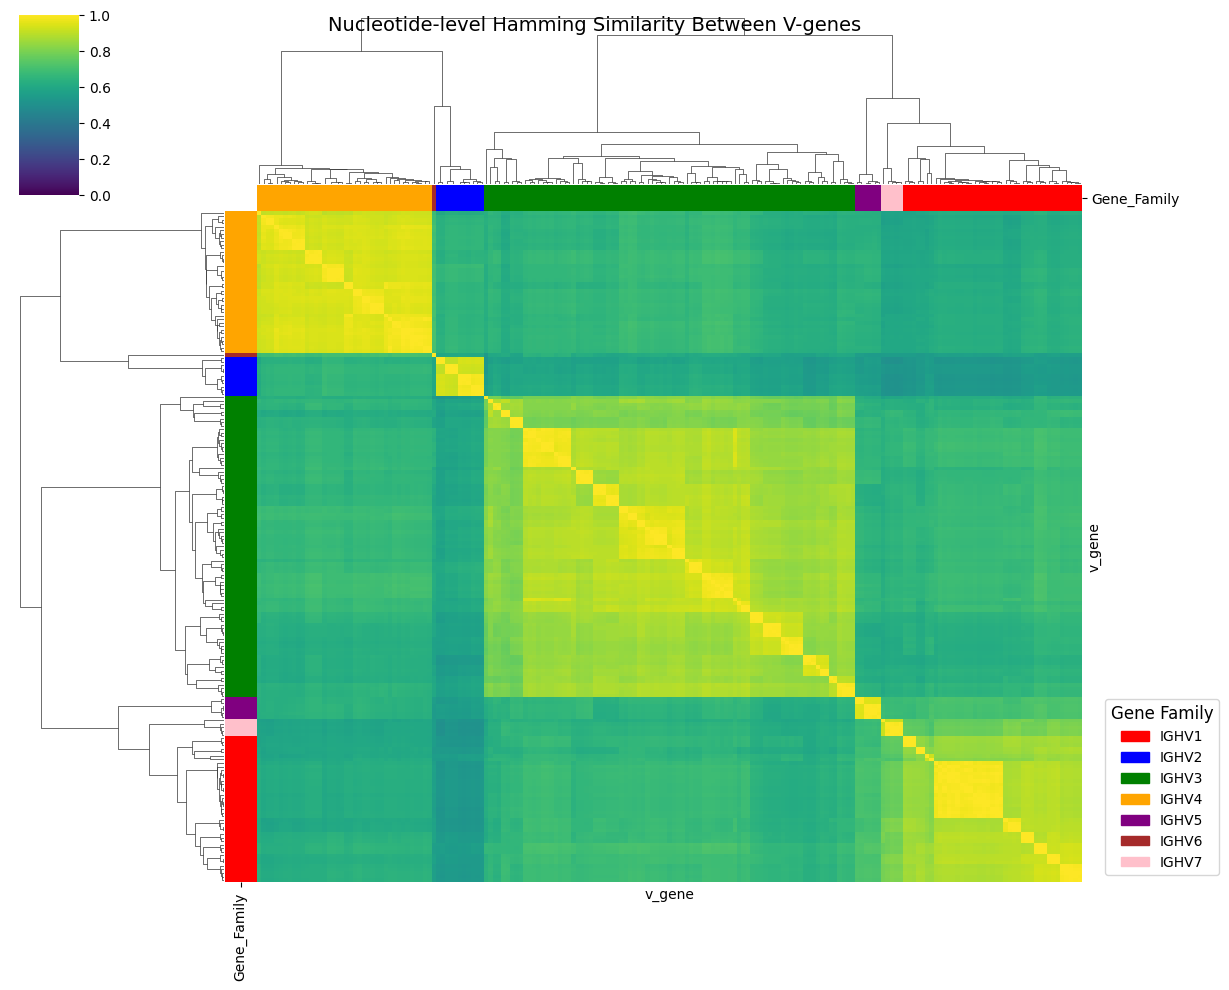

Gene family color mapping:
IGHV1: red
IGHV2: blue
IGHV3: green
IGHV4: orange
IGHV5: purple
IGHV6: brown
IGHV7: pink


/home/nharel/miniforge3/envs/netam_env/lib/python3.11/site-packages/seaborn/matrix.py:1124: UserWarning: ``square=True`` ignored in clustermap
  warnings.warn(msg)
/home/nharel/miniforge3/envs/netam_env/lib/python3.11/site-packages/seaborn/matrix.py:560: UserWarning: Clustering large matrix with scipy. Installing `fastcluster` may give better performance.
  warnings.warn(msg)
/home/nharel/miniforge3/envs/netam_env/lib/python3.11/site-packages/seaborn/matrix.py:560: UserWarning: Clustering large matrix with scipy. Installing `fastcluster` may give better performance.
  warnings.warn(msg)


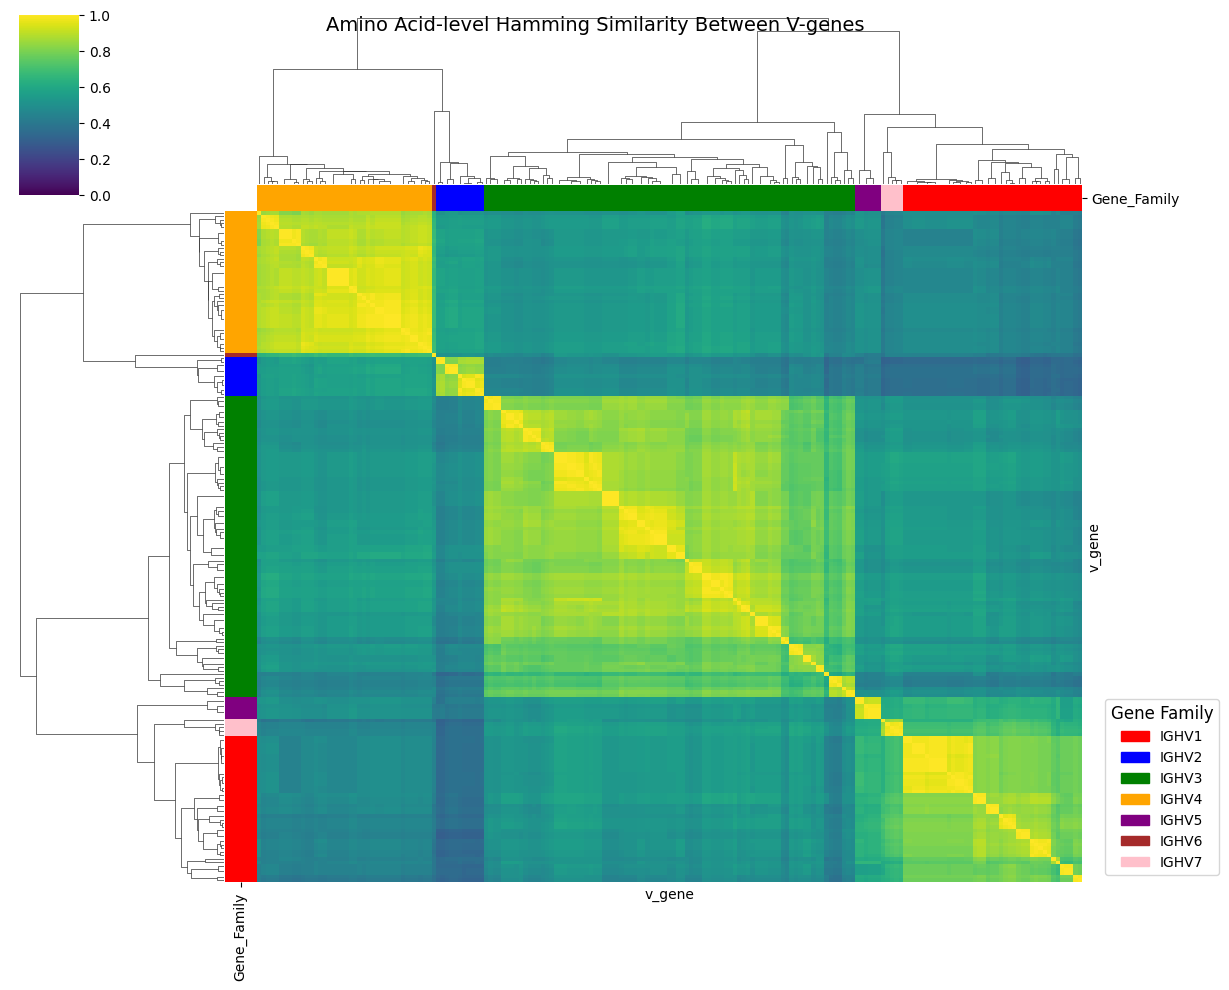

Gene family color mapping:
IGHV1: red
IGHV2: blue
IGHV3: green
IGHV4: orange
IGHV5: purple
IGHV6: brown
IGHV7: pink


/home/nharel/miniforge3/envs/netam_env/lib/python3.11/site-packages/seaborn/matrix.py:1124: UserWarning: ``square=True`` ignored in clustermap
  warnings.warn(msg)
/home/nharel/miniforge3/envs/netam_env/lib/python3.11/site-packages/seaborn/matrix.py:560: UserWarning: Clustering large matrix with scipy. Installing `fastcluster` may give better performance.
  warnings.warn(msg)
/home/nharel/miniforge3/envs/netam_env/lib/python3.11/site-packages/seaborn/matrix.py:560: UserWarning: Clustering large matrix with scipy. Installing `fastcluster` may give better performance.
  warnings.warn(msg)


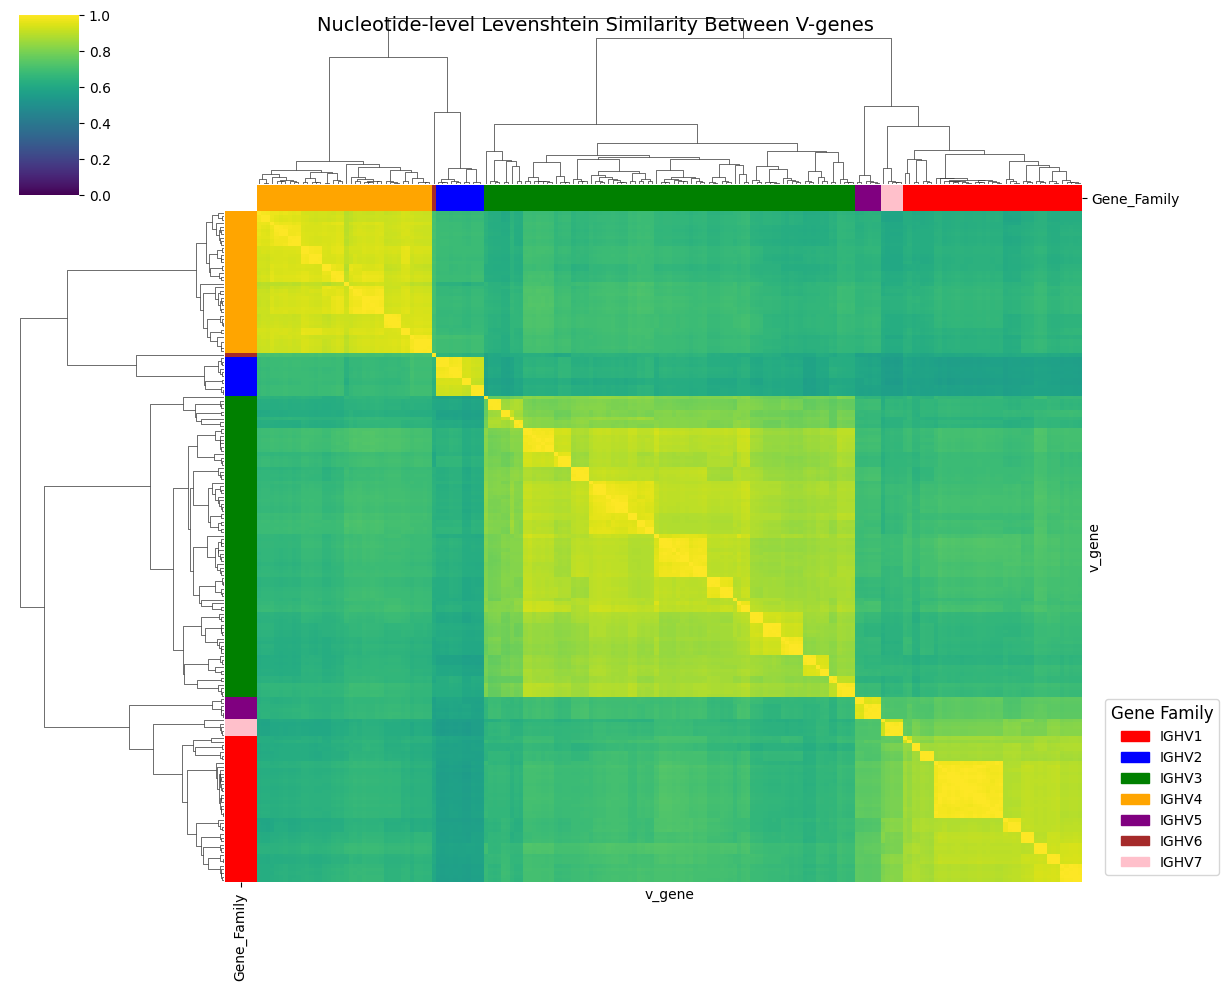

Gene family color mapping:
IGHV1: red
IGHV2: blue
IGHV3: green
IGHV4: orange
IGHV5: purple
IGHV6: brown
IGHV7: pink


/home/nharel/miniforge3/envs/netam_env/lib/python3.11/site-packages/seaborn/matrix.py:1124: UserWarning: ``square=True`` ignored in clustermap
  warnings.warn(msg)
/home/nharel/miniforge3/envs/netam_env/lib/python3.11/site-packages/seaborn/matrix.py:560: UserWarning: Clustering large matrix with scipy. Installing `fastcluster` may give better performance.
  warnings.warn(msg)
/home/nharel/miniforge3/envs/netam_env/lib/python3.11/site-packages/seaborn/matrix.py:560: UserWarning: Clustering large matrix with scipy. Installing `fastcluster` may give better performance.
  warnings.warn(msg)


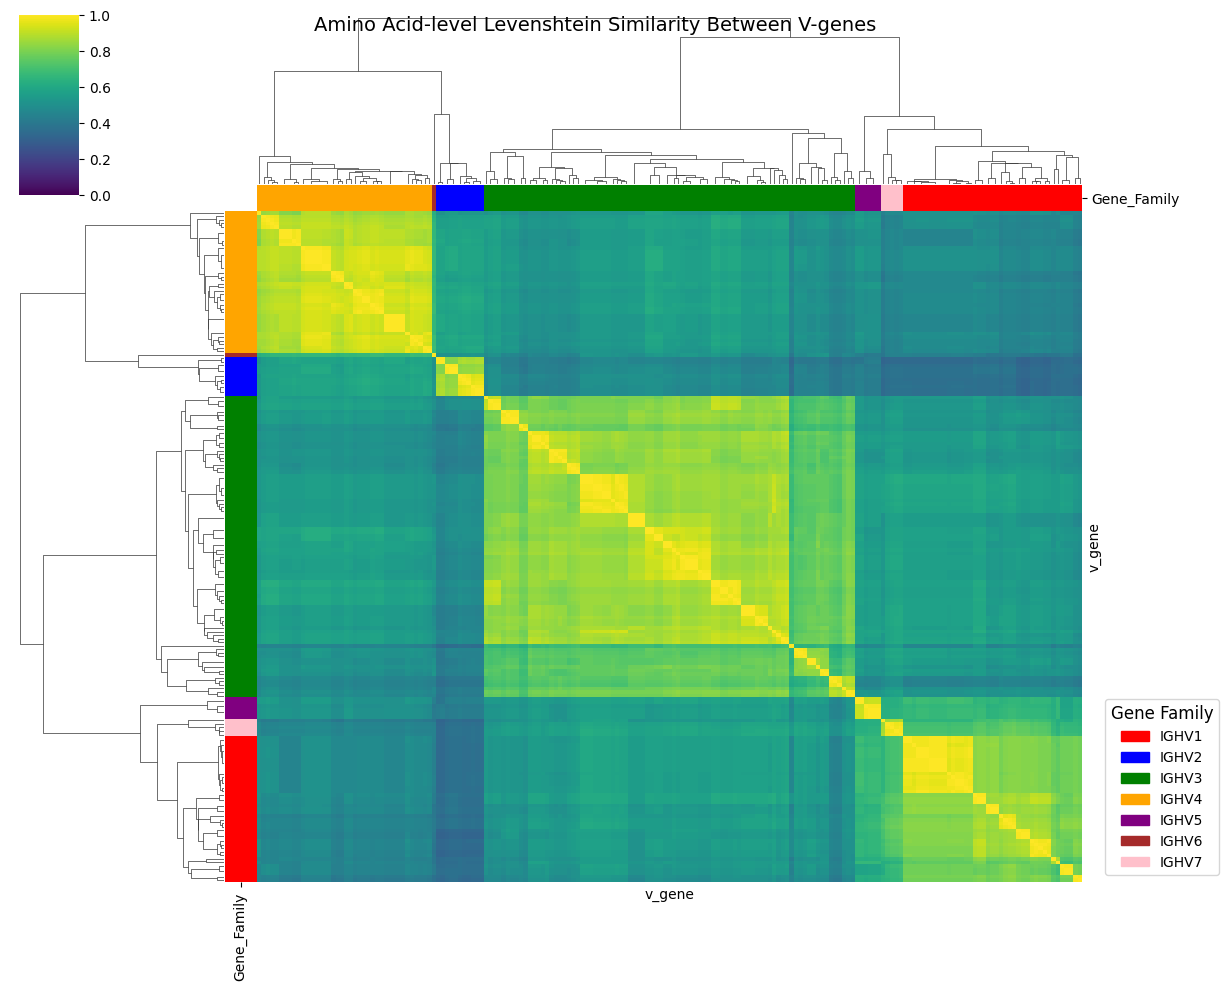

Gene family color mapping:
IGHV1: red
IGHV2: blue
IGHV3: green
IGHV4: orange
IGHV5: purple
IGHV6: brown
IGHV7: pink


In [7]:


def plot_similarity_clustermap(similarity_df, codons_df, title):
    """
    Plot a clustermap of gene similarity with gene family color bars.
    
    Args:
        similarity_df : DataFrame (square similarity matrix, index = v_genes)
        codons_df : DataFrame containing ['v_gene', 'v_family']
        title : str, title for the plot
    """
    
    # --- Gene family dictionary ---
    gene_family_dict = {i[1]: i[2] 
                        for i in list(codons_df[['v_gene', 'v_family']]
                                      .drop_duplicates().itertuples())}
    
    # Clean allele info (*01, *02, etc.)
    gene_family_dict_clean = {gene.split('*')[0]: family 
                              for gene, family in gene_family_dict.items()}
    
    # Unique families → assign colors
    unique_families = sorted(set(gene_family_dict_clean.values()))
    named_colors = ['red', 'blue', 'green', 'orange', 'purple', 
                    'brown', 'pink', 'gray', 'cyan', 'olive']
    category_colors_named = dict(zip(unique_families, 
                                     named_colors[:len(unique_families)]))
    
    # Cleaned gene names for mapping
    clean_index = [gene.split('*')[0] for gene in similarity_df.index]
    clean_columns = [gene.split('*')[0] for gene in similarity_df.columns]
    
    # Row & column colors
    row_colors_df = pd.DataFrame({
        'Gene_Family': pd.Series(clean_index, index=similarity_df.index)
                          .map(gene_family_dict_clean)
                          .map(category_colors_named)
    })
    col_colors_df = pd.DataFrame({
        'Gene_Family': pd.Series(clean_columns, index=similarity_df.columns)
                          .map(gene_family_dict_clean)
                          .map(category_colors_named)
    })
    
    # --- Clustermap ---
    g = sns.clustermap(similarity_df,
                       cmap='viridis',
                       square=True,
                       xticklabels=False,
                       yticklabels=False,
                       row_colors=row_colors_df,
                       col_colors=col_colors_df,
                       figsize=(12, 10),
                       vmin=0, vmax=1)
    
    # Title
    g.fig.suptitle(title, fontsize=14, y=0.98)
    
    # Legend for families
    legend_patches = [mpatches.Patch(color=color, label=family) 
                      for family, color in sorted(category_colors_named.items())]
    
    g.ax_heatmap.legend(handles=legend_patches,
                        bbox_to_anchor=(1.02, 0), 
                        loc='lower left',
                        title='Gene Family',
                        title_fontsize=12,
                        fontsize=10)
    
    plt.show()
    
    # Print mapping for reproducibility
    print("Gene family color mapping:")
    for family, color in sorted(category_colors_named.items()):
        print(f"{family}: {color}")

# --- Use it for your 4 similarity matrices ---
plot_similarity_clustermap(distance_hamming_nucleotide, codons_df, 
                           "Nucleotide-level Hamming Similarity Between V-genes")

plot_similarity_clustermap(distance_hamming_aa, codons_df, 
                           "Amino Acid-level Hamming Similarity Between V-genes")

plot_similarity_clustermap(distance_levenshtein_nucleotide, codons_df, 
                           "Nucleotide-level Levenshtein Similarity Between V-genes")

plot_similarity_clustermap(distance_levenshtein_aa, codons_df, 
                           "Amino Acid-level Levenshtein Similarity Between V-genes")


In [8]:

def plot_mirrored_vfamily_distribution(codons_df, v_family1, v_family2, figsize=(20, 4)):
    """
    Create a mirrored histogram showing amino acid distribution for two V families.
    v_family1 bars go above x-axis, v_family2 bars go below x-axis.
    
    Handles both integer sites (IMGT) and string sites with insertion codes (Chothia).
    Properly sorts sites to maintain biological ordering (e.g., 1, 1A, 2, 3, 3A, 4).
    """
    
    fig, ax = plt.subplots(figsize=figsize)
    
    # Filter data for each family
    family1_data = codons_df[codons_df.v_family == v_family1].copy()
    family2_data = codons_df[codons_df.v_family == v_family2].copy()
    
    # Get all unique sites and sort them properly
    all_sites = list(codons_df['site'].unique())
    all_sites_ordered = sort_antibody_sites(all_sites)
    
    # Create a mapping from site to integer position for plotting
    site_to_pos = {site: i for i, site in enumerate(all_sites_ordered)}
    positions = list(range(len(all_sites_ordered)))
    
    # Get all unique amino acids from both families
    all_amino_acids = sorted(set(family1_data['amino_acid'].unique()) | 
                           set(family2_data['amino_acid'].unique()))
    
    # Use tab20 colormap
    colors = plt.cm.tab20(np.linspace(0, 1, len(all_amino_acids)))
    color_map = dict(zip(all_amino_acids, colors))
    
    # Calculate counts for family1 (above x-axis)
    family1_counts = {aa: np.zeros(len(all_sites_ordered), dtype=float) for aa in all_amino_acids}
    family1_totals = np.zeros(len(all_sites_ordered), dtype=float)
    
    for aa in all_amino_acids:
        aa_data = family1_data[family1_data['amino_acid'] == aa]
        for _, row in aa_data.iterrows():
            if row['site'] in site_to_pos:
                pos = site_to_pos[row['site']]
                family1_counts[aa][pos] += 1
                family1_totals[pos] += 1
    
    # Convert to percentages
    for aa in all_amino_acids:
        family1_counts[aa] = np.divide(family1_counts[aa], family1_totals, 
                                     out=np.zeros_like(family1_counts[aa], dtype=float), 
                                     where=family1_totals!=0) * 100
    
    # Calculate counts for family2 (below x-axis)
    family2_counts = {aa: np.zeros(len(all_sites_ordered), dtype=float) for aa in all_amino_acids}
    family2_totals = np.zeros(len(all_sites_ordered), dtype=float)
    
    for aa in all_amino_acids:
        aa_data = family2_data[family2_data['amino_acid'] == aa]
        for _, row in aa_data.iterrows():
            if row['site'] in site_to_pos:
                pos = site_to_pos[row['site']]
                family2_counts[aa][pos] += 1
                family2_totals[pos] += 1
    
    # Convert to percentages and make negative
    for aa in all_amino_acids:
        family2_counts[aa] = -np.divide(family2_counts[aa], family2_totals, 
                                      out=np.zeros_like(family2_counts[aa], dtype=float), 
                                      where=family2_totals!=0) * 100
    
    # Plot both families
    # Plot family1 above x-axis (positive values) - stack them
    bottom1 = np.zeros(len(all_sites_ordered))
    for aa in all_amino_acids:
        if np.any(family1_counts[aa] > 0):
            ax.bar(positions, family1_counts[aa], bottom=bottom1, 
                  color=color_map[aa], alpha=0.8, width=0.8, 
                  edgecolor='black', linewidth=0.5)
            bottom1 += family1_counts[aa]
    
    # Plot family2 below x-axis (negative values) - stack them
    bottom2 = np.zeros(len(all_sites_ordered))
    for aa in all_amino_acids:
        if np.any(family2_counts[aa] < 0):
            ax.bar(positions, family2_counts[aa], bottom=bottom2, 
                  color=color_map[aa], alpha=0.8, width=0.8, 
                  edgecolor='black', linewidth=0.5)
            bottom2 += family2_counts[aa]
    
    # Customize the plot
    ax.set_xlabel('Site Position', fontsize=12)
    ax.set_ylabel(f'Percentage\n{v_family1} (above) | {v_family2} (below)', fontsize=12)
    ax.set_title(f'Amino Acid Distribution: {v_family1} vs {v_family2}', fontsize=14)
    ax.axhline(y=0, color='black', linestyle='-', alpha=0.8, linewidth=1)
    ax.grid(True, alpha=0.3, axis='y')
    
    # Set x-axis ticks - show every 5th position with original site labels
    tick_positions = list(range(0, len(all_sites_ordered), 5))
    tick_labels = [str(all_sites_ordered[i]) for i in tick_positions]
    ax.set_xticks(tick_positions)
    ax.set_xticklabels(tick_labels, rotation=90)
    
    # Create legend for amino acids
    legend_handles = []
    legend_labels = []
    for aa in all_amino_acids:
        legend_handles.append(plt.Rectangle((0,0),1,1, facecolor=color_map[aa], 
                                          edgecolor='black', linewidth=0.5, alpha=0.8))
        legend_labels.append(aa)
    
    ax.legend(legend_handles, legend_labels, bbox_to_anchor=(1.05, 1), loc='upper left', 
              title='Amino Acids')
    
    plt.tight_layout()
    plt.show()
    
    return fig, ax

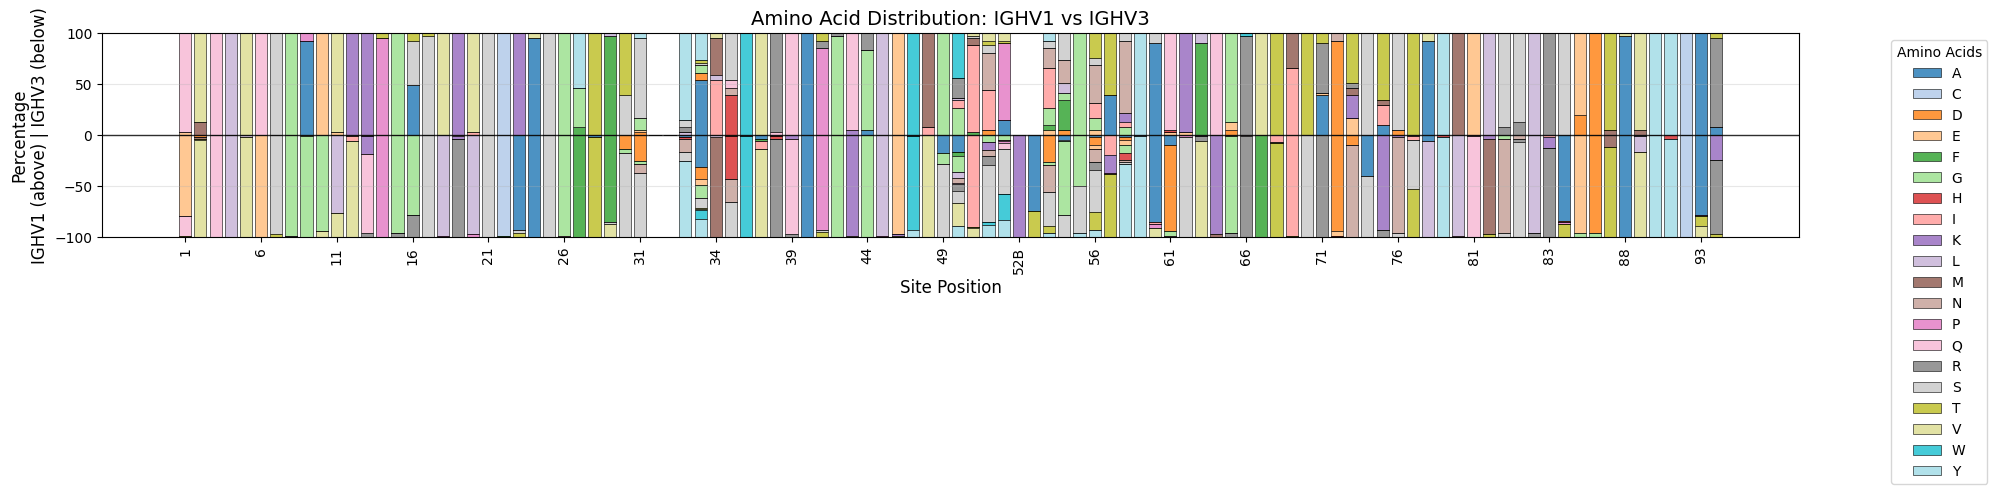

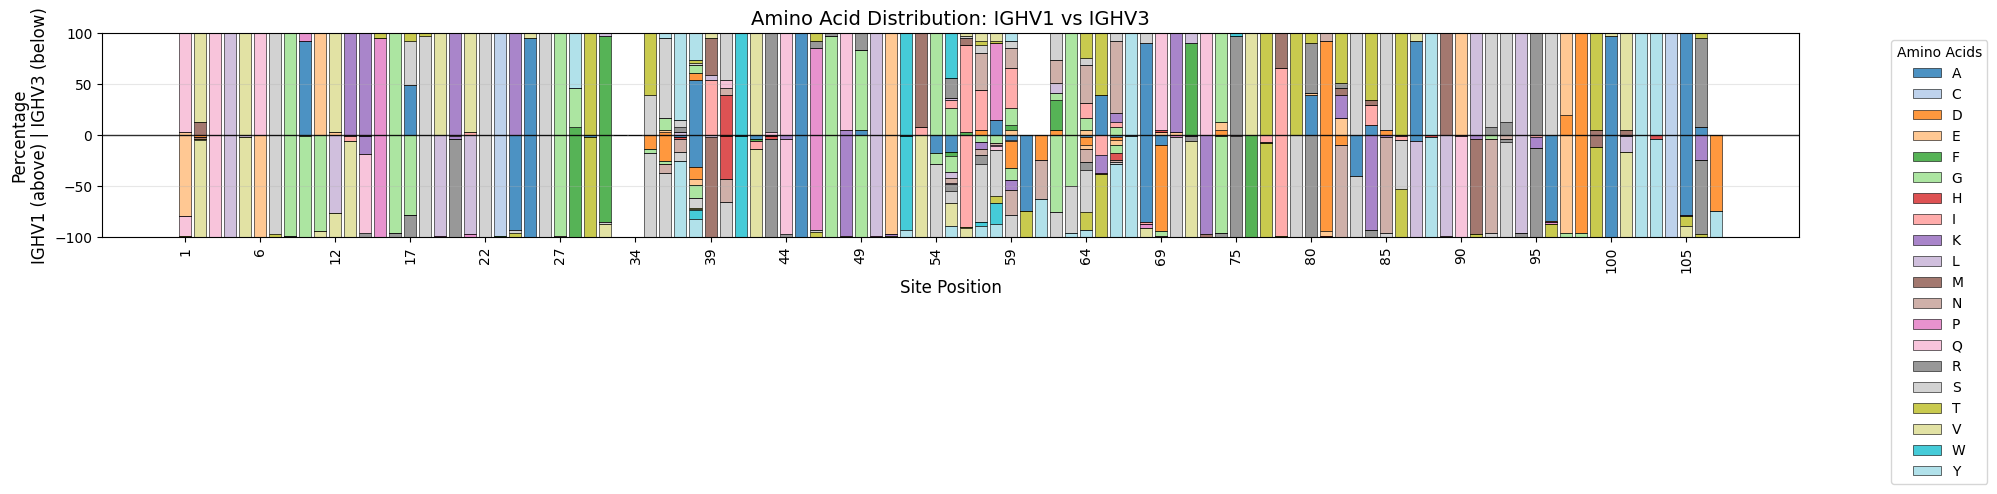

In [9]:
codons_df_chothia = pd.read_csv(localify(f"germline/germline_codons_chothia.csv"))

fig, ax = plot_mirrored_vfamily_distribution(codons_df_chothia, 'IGHV1', 'IGHV3')
#fig, ax = plot_mirrored_vfamily_distribution(codons_df_chothia, 'IGHV3', 'IGHV4')


codons_df_imgt = pd.read_csv(localify(f"germline/germline_codons_imgt.csv"))

fig, ax = plot_mirrored_vfamily_distribution(codons_df_imgt, 'IGHV1', 'IGHV3')
#fig, ax = plot_mirrored_vfamily_distribution(codons_df_imgt, 'IGHV3', 'IGHV4')

In [10]:
## imgt
if numbering_scheme == 'imgt':
    #sites_of_interest = ['38', '40', '55','57', '64','66', '106']
    sites_of_interest = ['38', '40', '55','57', '64','66']

    sites_of_interest = ['38', '40', '55','57']
    #sites_of_interest = ['38', '40']
    #sites_of_interest = ['38', '55']
elif numbering_scheme == 'chothia':
    sites_of_interest = ['33', '35', '50', '52', '56', '58']
    #sites_of_interest = ['33', '35', '50', '52', '56', '94']
    sites_of_interest = ['33', '35']
    #sites_of_interest = ['50', '52']

    #sites_of_interest = ['33', '35', '50', '52']
    
    #sites_of_interest = ['33', '50']
    sites_of_interest = ['71', '72', '73', '74', '75']
    #sites_of_interest = ['71', '73', '75']



temp_df = codons_df[['v_gene', 'amino_acid', 'site', 'v_family']]
#temp_df = temp_df[temp_df.v_family.isin(['IGHV1', 'IGHV3', 'IGHV4'])]
temp_df = temp_df[temp_df.v_family.isin(['IGHV1', 'IGHV3'])]

temp_df = temp_df[temp_df.site.isin(sites_of_interest)]
temp_df = temp_df.pivot(index='v_gene', columns='site', values='amino_acid')
temp_df['v_family'] = temp_df.index.str.split('-').str[0]


temp_df = temp_df.groupby(sites_of_interest + ['v_family']).size().reset_index(name='counts').sort_values(by='counts', ascending=False)
#temp_df = temp_df.groupby(sites_of_interest).size().reset_index(name='counts').sort_values(by='counts', ascending=False)


In [11]:
# Define amino acid groups by chemical properties
aa_groups = {
    'Nonpolar': ['A', 'V', 'I', 'L', 'M', 'F', 'W', 'P', 'G'],
    'Polar': ['S', 'T', 'C', 'Y', 'N', 'Q'],
    'Positive': ['K', 'R', 'H'],
    'Negative': ['D', 'E']
}

# Assign colors to groups
group_colors = {
    'Nonpolar': '#FFE4B5',
    'Polar': '#98FB98',
    'Positive': '#87CEEB',
    'Negative': '#FFB6C1'
}

# Create reverse mapping for amino acids
aa_color_map = {}
for group, aas in aa_groups.items():
    for aa in aas:
        aa_color_map[aa] = group_colors[group]

# Create color map for v_family
import seaborn as sns
import matplotlib.colors as mcolors

unique_families = temp_df['v_family'].unique()
family_palette = sns.color_palette("tab20", len(unique_families))
family_color_map = {family: mcolors.rgb2hex(color) for family, color in zip(unique_families, family_palette)}

# Define site columns
# Apply styling to amino acid columns
styled_df = temp_df.style.applymap(
    lambda x: f'background-color: {aa_color_map.get(x, "white")}' if pd.notna(x) else '',
    subset=sites_of_interest
)

# Apply styling to v_family column
styled_df = styled_df.applymap(
    lambda x: f'background-color: {family_color_map.get(x, "white")}' if pd.notna(x) else '',
    subset=['v_family']
)

# Display with caption
styled_df.set_caption("Amino acids colored by chemical properties: "
                      "🟡 Nonpolar | 🟢 Polar | 🔵 Positive | 🔴 Negative | V-families colored by family")

styled_df

/loc/scratch/48643626/ipykernel_16987/4097626320.py:33: FutureWarning: Styler.applymap has been deprecated. Use Styler.map instead.
  styled_df = temp_df.style.applymap(
/loc/scratch/48643626/ipykernel_16987/4097626320.py:39: FutureWarning: Styler.applymap has been deprecated. Use Styler.map instead.
  styled_df = styled_df.applymap(


,71,72,73,74,75,v_family,counts
7,R,D,N,S,K,IGHV3,36
6,R,D,N,A,K,IGHV3,30
1,A,D,K,S,T,IGHV1,9
4,R,D,D,S,K,IGHV3,8
0,A,D,E,S,T,IGHV1,6
8,R,D,N,S,R,IGHV3,6
11,R,D,T,S,I,IGHV1,5
10,R,D,T,S,A,IGHV1,4
13,R,E,N,A,K,IGHV3,4
5,R,D,M,S,T,IGHV1,3


In [12]:
import seaborn as sns
import matplotlib.colors as mcolors
from IPython.display import display, HTML

# All 20 standard amino acids
amino_acids = ['A', 'C', 'D', 'E', 'F', 'G', 'H', 'I', 'K', 'L', 
               'M', 'N', 'P', 'Q', 'R', 'S', 'T', 'V', 'W', 'Y']

# Create a distinct color for each amino acid using pastel palette
aa_palette = sns.color_palette("pastel", len(amino_acids))
aa_color_map = {aa: mcolors.rgb2hex(color) for aa, color in zip(amino_acids, aa_palette)}

def style_table(df, title):
    """Apply consistent styling to a dataframe"""
    # Drop v_family column since it's in the title
    df = df.drop(columns=['v_family'])
    
    styled = df.style.applymap(
        lambda x: f'background-color: {aa_color_map.get(x, "white")}' if pd.notna(x) else '',
        subset=sites_of_interest
    )
    styled = styled.background_gradient(subset=['counts'], cmap='Blues')
    styled = styled.set_caption(title)
    styled = styled.hide(axis='index')
    return styled

# Split by v_family
ighv1_df = temp_df[temp_df['v_family'] == 'IGHV1'].copy()
ighv3_df = temp_df[temp_df['v_family'] == 'IGHV3'].copy()

# Render tables to HTML
ighv1_html = style_table(ighv1_df, "IGHV1").to_html()
ighv3_html = style_table(ighv3_df, "IGHV3").to_html()

# Display side by side using HTML
display(HTML(f"""
<div style="display: flex; gap: 40px; align-items: flex-start;">
    <div>{ighv1_html}</div>
    <div>{ighv3_html}</div>
</div>
"""))


/loc/scratch/48643626/ipykernel_16987/2560949315.py:18: FutureWarning: Styler.applymap has been deprecated. Use Styler.map instead.
  styled = df.style.applymap(
/loc/scratch/48643626/ipykernel_16987/2560949315.py:18: FutureWarning: Styler.applymap has been deprecated. Use Styler.map instead.
  styled = df.style.applymap(


71,72,73,74,75,counts
A,D,K,S,T,9
A,D,E,S,T,6
R,D,T,S,I,5
R,D,T,S,A,4
R,D,M,S,T,3
R,N,T,S,I,3
T,D,T,S,T,3
R,D,T,S,T,3
R,D,R,S,M,2
E,D,T,S,T,1


In [13]:
## imgt
if numbering_scheme == 'imgt':
    pass
elif numbering_scheme == 'chothia':
    #sites_of_interest = ['33', '52']

    sites_of_interest = ['33', '50', '52']



temp_df = codons_df[['v_gene', 'amino_acid', 'site', 'v_family']]
#temp_df = temp_df[temp_df.v_family.isin(['IGHV1', 'IGHV3', 'IGHV4'])]
temp_df = temp_df[temp_df.v_family.isin(['IGHV1', 'IGHV3'])]

temp_df = temp_df[temp_df.site.isin(sites_of_interest)]
temp_df = temp_df.pivot(index='v_gene', columns='site', values='amino_acid')
temp_df['v_family'] = temp_df.index.str.split('-').str[0]


temp_df = temp_df.groupby(sites_of_interest + ['v_family']).size().reset_index(name='counts').sort_values(by='counts', ascending=False)
#temp_df = temp_df.groupby(sites_of_interest).size().reset_index(name='counts').sort_values(by='counts', ascending=False)


In [14]:
import seaborn as sns
import matplotlib.colors as mcolors
from IPython.display import display, HTML

# All 20 standard amino acids
amino_acids = ['A', 'C', 'D', 'E', 'F', 'G', 'H', 'I', 'K', 'L', 
               'M', 'N', 'P', 'Q', 'R', 'S', 'T', 'V', 'W', 'Y']

# Create a distinct color for each amino acid using pastel palette
aa_palette = sns.color_palette("tab20", len(amino_acids))
aa_color_map = {aa: mcolors.rgb2hex(color) for aa, color in zip(amino_acids, aa_palette)}

def style_table(df, title):
    """Apply consistent styling to a dataframe"""
    # Drop v_family column since it's in the title
    df = df.drop(columns=['v_family'])
    
    styled = df.style.applymap(
        lambda x: f'background-color: {aa_color_map.get(x, "white")}' if pd.notna(x) else '',
        subset=sites_of_interest
    )
    styled = styled.background_gradient(subset=['counts'], cmap='Blues')
    styled = styled.set_caption(title)
    styled = styled.hide(axis='index')
    return styled

# Split by v_family
ighv1_df = temp_df[temp_df['v_family'] == 'IGHV1'].copy()
ighv3_df = temp_df[temp_df['v_family'] == 'IGHV3'].copy()

# Render tables to HTML
ighv1_html = style_table(ighv1_df, "IGHV1").to_html()
ighv3_html = style_table(ighv3_df, "IGHV3").to_html()

# Display side by side using HTML
display(HTML(f"""
<div style="display: flex; gap: 40px; align-items: flex-start;">
    <div>{ighv1_html}</div>
    <div>{ighv3_html}</div>
</div>
"""))


/loc/scratch/48643626/ipykernel_16987/4253241624.py:18: FutureWarning: Styler.applymap has been deprecated. Use Styler.map instead.
  styled = df.style.applymap(
/loc/scratch/48643626/ipykernel_16987/4253241624.py:18: FutureWarning: Styler.applymap has been deprecated. Use Styler.map instead.
  styled = df.style.applymap(


33,50,52,counts
A,G,I,10
A,R,I,5
A,W,N,4
G,W,S,3
Y,I,N,3
Y,W,N,3
D,W,N,3
A,W,V,3
Y,W,T,2
Y,R,N,2


## Experiments, not currently used

First 30 available positions:
['1', '2', '3', '4', '5', '6', '7', '8', '9', '10', '11', '12', '13', '14', '15', '16', '17', '18', '19', '20', '21', '22', '23', '24', '25', '26', '27', '28', '29', '30']

Analyzing all pairwise LD...
Analyzing all 102 positions
Analyzing 7 families with >= 5 genes
Processing IGHV3...


Processing IGHV1...


Processing IGHV4...


Processing IGHV2...


Processing IGHV5...


Processing IGHV7...


Processing IGHV6...

Analyzed 5296 position pairs

Top 20 highest LD pairs:
     entity pos1 pos2  cramers_v       p_value
550   IGHV3   18   50        1.0  1.631469e-14
956   IGHV3   26   50        1.0  1.631469e-14
1766  IGHV3   43   50        1.0  1.631469e-14
62    IGHV3    1   80        1.0  3.487262e-19
234   IGHV3   12   18        1.0  3.487262e-19
240   IGHV3   12   26        1.0  3.487262e-19
249   IGHV3   12   36        1.0  3.487262e-19
254   IGHV3   12   43        1.0  3.487262e-19
263   IGHV3   12  52A        1.0  2.695166e-12
270   IGHV3   12   59        1.0  3.487262e-19
279   IGHV3   12   69        1.0  3.487262e-19
364   IGHV3   13   80        1.0  2.595112e-18
440   IGHV3   15  82B        1.0  3.487262e-19
526   IGHV3   18    2        1.0  2.595112e-18
547   IGHV3   18   47        1.0  3.487262e-19
553   IGHV3   18  52A        1.0  2.695166e-12
561   IGHV3   18   60        1.0  2.595112e-18
564   IGHV3   18   63        1.0  3.487262e-19
566   IGHV3   18   65        1.

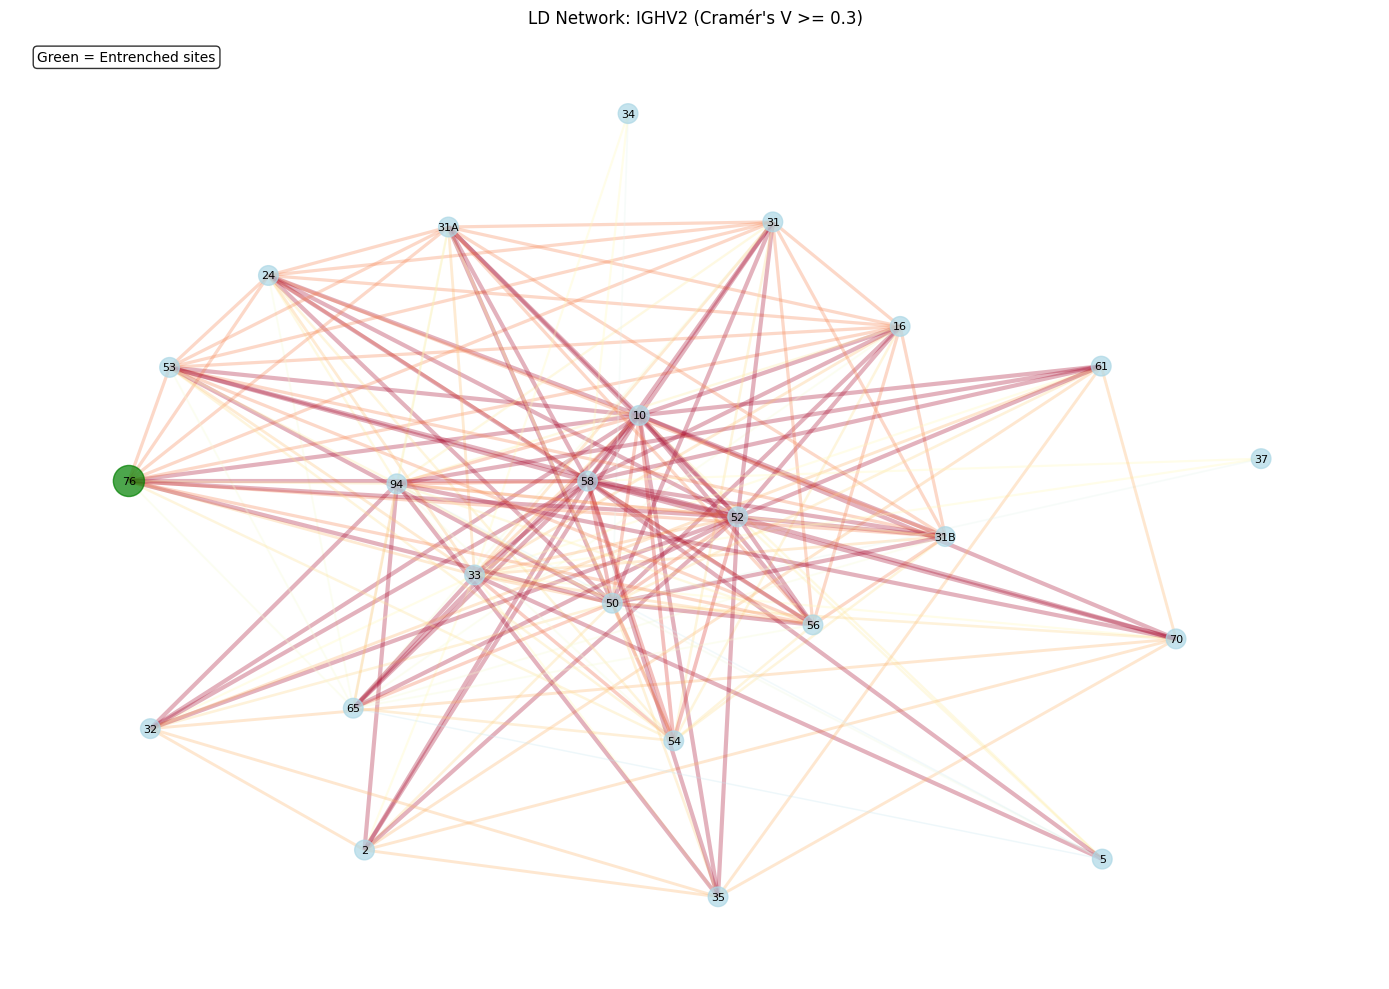

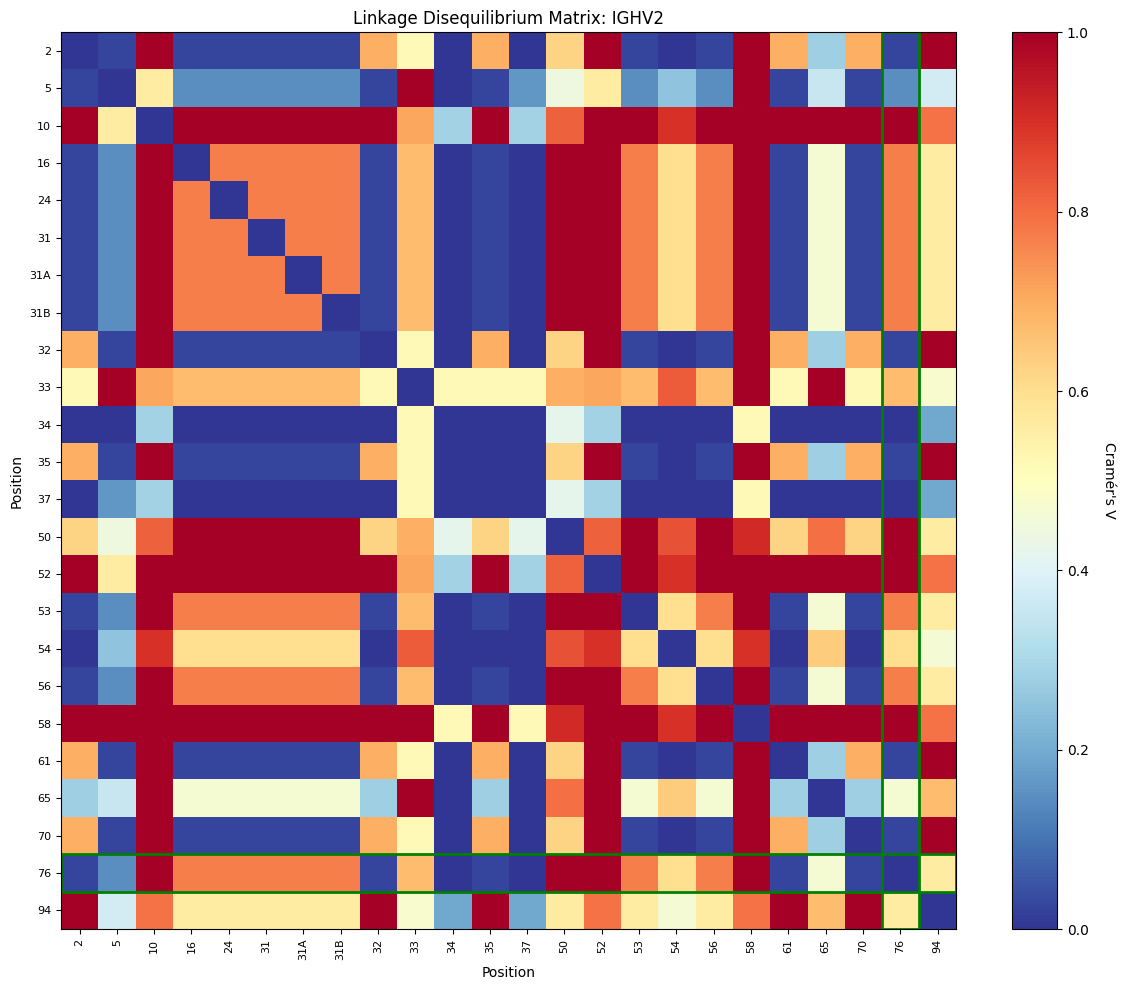

In [15]:
import pandas as pd
import numpy as np
from scipy.stats import chi2_contingency
from itertools import combinations
import seaborn as sns
import matplotlib.pyplot as plt

class IGHVLinkageAnalyzer:
    def __init__(self, codons_df):
        """
        Parameters:
        -----------
        codons_df : pd.DataFrame
            DataFrame with columns: site, codon, v_gene, v_family, amino_acid
            site can be string (e.g., "52A", "64", etc.)
        """
        self.codons_df = codons_df.copy()
        self.codons_df['gene_allele'] = self.codons_df['v_gene']
        # Ensure site is string type
        self.codons_df['site'] = self.codons_df['site'].astype(str)
        
    def get_all_positions(self):
        """Get all available positions in the data"""
        return sorted(self.codons_df['site'].unique(), key=self._sort_key)
    
    def _sort_key(self, site):
        """
        Sort sites naturally (1, 2, 10, 52A, 52B, etc.)
        """
        import re
        # Extract numeric and alphabetic parts
        match = re.match(r'(\d+)([A-Z]?)', str(site))
        if match:
            num, letter = match.groups()
            return (int(num), letter if letter else '')
        return (float('inf'), str(site))
    
    def extract_residues_for_gene_set(self, gene_names, positions=None):
        """
        Extract residues for multiple genes (e.g., all genes in a family)
        
        Parameters:
        -----------
        gene_names : list
            List of gene names
        positions : list or None
            If None, use all positions
        """
        if positions is None:
            positions = self.get_all_positions()
        
        # Ensure positions are strings
        positions = [str(p) for p in positions]
        
        all_data = []
        
        for gene_name in gene_names:
            gene_data = self.codons_df[self.codons_df['v_gene'] == gene_name]
            
            if len(gene_data) == 0:
                continue
            
            # Filter for positions
            position_data = gene_data[gene_data['site'].isin(positions)]
            
            # Pivot to get one row per gene
            pivot = position_data.pivot_table(
                index='v_gene',
                columns='site',
                values='amino_acid',
                aggfunc='first'
            )
            
            if len(pivot) > 0:
                all_data.append(pivot)
        
        if not all_data:
            return None
            
        result = pd.concat(all_data)
        # Rename columns to be consistent
        result.columns = [f'pos_{col}' for col in result.columns]
        result = result.reset_index()
        
        return result
    
    def calculate_all_pairwise_ld(self, df, entity_name="", max_pairs=None):
        """
        Calculate LD for all pairs of positions in the dataframe
        
        Parameters:
        -----------
        df : pd.DataFrame
            DataFrame with residues at positions
        entity_name : str
            Name for this analysis
        max_pairs : int or None
            Maximum number of pairs to analyze (for computational efficiency)
            
        Returns:
        --------
        DataFrame with LD statistics
        """
        if df is None or len(df) < 3:
            return None
        
        # Get all position columns
        pos_cols = [col for col in df.columns if col.startswith('pos_')]
        # Extract site names (remove 'pos_' prefix)
        positions = [col.replace('pos_', '') for col in pos_cols]
        
        # Generate all pairs
        all_pairs = list(combinations(range(len(positions)), 2))
        
        # Optionally subsample for efficiency
        if max_pairs and len(all_pairs) > max_pairs:
            print(f"  Subsampling {max_pairs} pairs from {len(all_pairs)} total pairs")
            np.random.seed(42)
            pair_indices = np.random.choice(len(all_pairs), max_pairs, replace=False)
            all_pairs = [all_pairs[i] for i in pair_indices]
        
        results = []
        for i, j in all_pairs:
            pos1, pos2 = positions[i], positions[j]
            col1, col2 = pos_cols[i], pos_cols[j]
            
            # Remove missing values
            mask = df[col1].notna() & df[col2].notna()
            filtered = df[mask]
            
            if len(filtered) < 3:
                continue
            
            # Build contingency table
            contingency = pd.crosstab(filtered[col1], filtered[col2])
            
            # Skip if no variation
            if contingency.shape[0] < 2 or contingency.shape[1] < 2:
                continue
            
            try:
                chi2, p_value, dof, expected = chi2_contingency(contingency)
                
                # Cramér's V
                n = contingency.sum().sum()
                min_dim = min(contingency.shape[0], contingency.shape[1]) - 1
                cramers_v = np.sqrt(chi2 / (n * min_dim)) if min_dim > 0 else 0
                
                results.append({
                    'entity': entity_name,
                    'pos1': pos1,
                    'pos2': pos2,
                    'chi2': chi2,
                    'p_value': p_value,
                    'cramers_v': cramers_v,
                    'n_sequences': len(filtered),
                    'n_states_pos1': contingency.shape[0],
                    'n_states_pos2': contingency.shape[1]
                })
            except:
                continue
        
        return pd.DataFrame(results) if results else None
    
    def analyze_by_family(self, positions=None, min_genes=5, max_pairs=None):
        """
        Analyze LD patterns by V gene family across all (or specified) positions
        
        Parameters:
        -----------
        positions : list or None
            If None, analyze all positions. Can be strings like ["52A", "64", "71"]
        min_genes : int
            Minimum number of genes required in a family
        max_pairs : int or None
            Maximum pairs to analyze per family (for efficiency)
        """
        if positions is None:
            positions = self.get_all_positions()
            print(f"Analyzing all {len(positions)} positions")
        else:
            # Ensure positions are strings
            positions = [str(p) for p in positions]
        
        all_results = []
        
        # Get families with enough genes
        family_counts = self.codons_df['v_family'].value_counts()
        families = family_counts[family_counts >= min_genes].index
        
        print(f"Analyzing {len(families)} families with >= {min_genes} genes")
        
        for family in families:
            print(f"Processing {family}...")
            
            # Get all genes in this family
            genes_in_family = self.codons_df[
                self.codons_df['v_family'] == family
            ]['v_gene'].unique()
            
            # Extract residues
            df = self.extract_residues_for_gene_set(genes_in_family, positions)
            
            if df is not None and len(df) >= min_genes:
                results = self.calculate_all_pairwise_ld(df, family, max_pairs)
                if results is not None:
                    all_results.append(results)
        
        if not all_results:
            return None
            
        return pd.concat(all_results, ignore_index=True)
    
    def identify_ld_clusters(self, ld_results, entity_name, min_cramers_v=0.5):
        """
        Identify clusters of positions with high LD
        
        Parameters:
        -----------
        ld_results : pd.DataFrame
            Results from analyze_by_family
        entity_name : str
            Family/entity to analyze
        min_cramers_v : float
            Minimum Cramér's V to consider "linked"
        """
        entity_data = ld_results[
            (ld_results['entity'] == entity_name) & 
            (ld_results['cramers_v'] >= min_cramers_v)
        ]
        
        if len(entity_data) == 0:
            return None
        
        # Get unique positions involved in high LD pairs
        positions = sorted(
            set(entity_data['pos1'].tolist() + entity_data['pos2'].tolist()),
            key=self._sort_key
        )
        
        print(f"\n{entity_name}: Found {len(positions)} positions with high LD (Cramér's V >= {min_cramers_v})")
        print(f"Positions: {positions}")
        
        return positions
    
    def plot_ld_matrix(self, ld_results, entity_name, position_subset=None, 
                       annotate_entrenched=None):
        """
        Create a full LD matrix heatmap
        
        Parameters:
        -----------
        ld_results : pd.DataFrame
            Results from analyze_by_family
        entity_name : str
            Family to plot
        position_subset : list or None
            If provided, only plot these positions (can be strings)
        annotate_entrenched : list or None
            List of entrenched positions to highlight (can be strings)
        """
        entity_data = ld_results[ld_results['entity'] == entity_name]
        
        if len(entity_data) == 0:
            print(f"No data for {entity_name}")
            return
        
        # Get all positions (as strings)
        all_pos = sorted(
            set(entity_data['pos1'].tolist() + entity_data['pos2'].tolist()),
            key=self._sort_key
        )
        
        if position_subset:
            position_subset = [str(p) for p in position_subset]
            all_pos = [p for p in all_pos if p in position_subset]
        
        n_pos = len(all_pos)
        
        if n_pos > 100:
            print(f"Warning: {n_pos} positions will make a large plot. Consider using position_subset.")
        
        # Create matrices
        ld_matrix = np.zeros((n_pos, n_pos))
        p_matrix = np.ones((n_pos, n_pos))
        
        for _, row in entity_data.iterrows():
            if str(row['pos1']) not in all_pos or str(row['pos2']) not in all_pos:
                continue
            i = all_pos.index(str(row['pos1']))
            j = all_pos.index(str(row['pos2']))
            ld_matrix[i, j] = row['cramers_v']
            ld_matrix[j, i] = row['cramers_v']
            p_matrix[i, j] = row['p_value']
            p_matrix[j, i] = row['p_value']
        
        # Create figure
        fig, ax = plt.subplots(figsize=(max(12, n_pos/5), max(10, n_pos/5)))
        
        # Plot heatmap
        im = ax.imshow(ld_matrix, cmap='RdYlBu_r', vmin=0, vmax=1, aspect='auto')
        
        # Add colorbar
        cbar = plt.colorbar(im, ax=ax)
        cbar.set_label("Cramér's V", rotation=270, labelpad=20)
        
        # Set ticks
        tick_spacing = max(1, n_pos // 50)  # Don't show too many labels
        ax.set_xticks(range(0, n_pos, tick_spacing))
        ax.set_yticks(range(0, n_pos, tick_spacing))
        ax.set_xticklabels([all_pos[i] for i in range(0, n_pos, tick_spacing)], 
                          rotation=90, fontsize=8)
        ax.set_yticklabels([all_pos[i] for i in range(0, n_pos, tick_spacing)], 
                          fontsize=8)
        
        # Highlight entrenched positions if provided
        if annotate_entrenched:
            annotate_entrenched = [str(p) for p in annotate_entrenched]
            for pos in annotate_entrenched:
                if pos in all_pos:
                    idx = all_pos.index(pos)
                    # Draw boxes around entrenched positions
                    ax.add_patch(plt.Rectangle((idx-0.5, -0.5), 1, n_pos, 
                                              fill=False, edgecolor='green', linewidth=2))
                    ax.add_patch(plt.Rectangle((-0.5, idx-0.5), n_pos, 1, 
                                              fill=False, edgecolor='green', linewidth=2))
        
        ax.set_title(f'Linkage Disequilibrium Matrix: {entity_name}')
        ax.set_xlabel('Position')
        ax.set_ylabel('Position')
        
        plt.tight_layout()
        return fig
    
    def plot_ld_network(self, ld_results, entity_name, min_cramers_v=0.3, 
                       annotate_entrenched=None):
        """
        Plot positions as a network where edges represent LD
        
        Requires networkx: pip install networkx
        """
        try:
            import networkx as nx
        except ImportError:
            print("networkx not installed. Install with: pip install networkx")
            return
        
        entity_data = ld_results[
            (ld_results['entity'] == entity_name) & 
            (ld_results['cramers_v'] >= min_cramers_v)
        ]
        
        if len(entity_data) == 0:
            print(f"No edges with Cramér's V >= {min_cramers_v} for {entity_name}")
            return
        
        # Create graph
        G = nx.Graph()
        
        for _, row in entity_data.iterrows():
            G.add_edge(str(row['pos1']), str(row['pos2']), weight=row['cramers_v'])
        
        # Layout
        pos = nx.spring_layout(G, k=2, iterations=50, seed=42)
        
        # Plot
        fig, ax = plt.subplots(figsize=(14, 10))
        
        # Draw edges
        edges = G.edges()
        weights = [G[u][v]['weight'] for u, v in edges]
        nx.draw_networkx_edges(G, pos, alpha=0.3, width=[w*3 for w in weights], 
                              edge_color=weights,
                              edge_cmap=plt.cm.RdYlBu_r, edge_vmin=0, edge_vmax=1, ax=ax)
        
        # Draw nodes
        if annotate_entrenched:
            annotate_entrenched = [str(p) for p in annotate_entrenched]
        
        node_colors = ['green' if (annotate_entrenched and n in annotate_entrenched) 
                      else 'lightblue' for n in G.nodes()]
        node_sizes = [500 if (annotate_entrenched and n in annotate_entrenched) 
                     else 200 for n in G.nodes()]
        
        nx.draw_networkx_nodes(G, pos, node_color=node_colors, node_size=node_sizes, 
                              ax=ax, alpha=0.7)
        nx.draw_networkx_labels(G, pos, font_size=8, ax=ax)
        
        ax.set_title(f'LD Network: {entity_name} (Cramér\'s V >= {min_cramers_v})')
        ax.axis('off')
        
        if annotate_entrenched:
            ax.text(0.02, 0.98, 'Green = Entrenched sites', 
                   transform=ax.transAxes, fontsize=10,
                   verticalalignment='top',
                   bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))
        
        plt.tight_layout()
        return fig, G
    
    def compare_entrenched_vs_other(self, ld_results, entrenched_positions):
        """
        Compare LD involving entrenched sites vs other sites
        """
        # Convert to strings
        entrenched_positions = [str(p) for p in entrenched_positions]
        
        # Classify pairs
        def classify_pair(row):
            pos1, pos2 = str(row['pos1']), str(row['pos2'])
            if pos1 in entrenched_positions and pos2 in entrenched_positions:
                return 'both_entrenched'
            elif pos1 in entrenched_positions or pos2 in entrenched_positions:
                return 'one_entrenched'
            else:
                return 'neither_entrenched'
        
        ld_results['pair_type'] = ld_results.apply(classify_pair, axis=1)
        
        # Compare distributions
        summary = ld_results.groupby(['entity', 'pair_type']).agg({
            'cramers_v': ['mean', 'std', 'count'],
            'p_value': lambda x: (x < 0.05).sum()
        }).reset_index()
        
        summary.columns = ['entity', 'pair_type', 'mean_cramers_v', 'std_cramers_v', 
                          'n_pairs', 'n_significant']
        
        return summary
    
    def get_residue_frequencies(self, positions, by='v_family'):
        """
        Get residue frequencies at each position, grouped by family or gene
        
        Parameters:
        -----------
        positions : list
            List of positions to analyze (can be strings)
        by : str
            'v_family' or 'v_gene'
        """
        positions = [str(p) for p in positions]
        position_data = self.codons_df[self.codons_df['site'].isin(positions)]
        
        freq_tables = {}
        for pos in positions:
            pos_data = position_data[position_data['site'] == pos]
            freq = pos_data.groupby([by, 'amino_acid']).size().unstack(fill_value=0)
            freq_tables[pos] = freq
        
        return freq_tables


# Example usage:
if __name__ == "__main__":
    # Initialize
    analyzer = IGHVLinkageAnalyzer(codons_df)
    
    # Define your entrenched positions (can be strings like "52A")
    entrenched_positions = ["64", "66", "71", "73", "76"]  # Update these!
    
    print("First 30 available positions:")
    all_positions = analyzer.get_all_positions()
    print(all_positions[:30])
    
    # Analyze all positions by family
    print("\nAnalyzing all pairwise LD...")
    all_ld = analyzer.analyze_by_family(positions=None, min_genes=5, max_pairs=10000)
    
    if all_ld is not None:
        print(f"\nAnalyzed {len(all_ld)} position pairs")
        
        # Look at highest LD pairs
        print("\nTop 20 highest LD pairs:")
        top_pairs = all_ld.nlargest(20, 'cramers_v')[['entity', 'pos1', 'pos2', 'cramers_v', 'p_value']]
        print(top_pairs)
        
        # Compare entrenched vs other
        print("\nComparing LD for entrenched vs other positions...")
        comparison = analyzer.compare_entrenched_vs_other(all_ld, entrenched_positions)
        print("\nLD comparison (entrenched vs other):")
        print(comparison)
        
        # Pick a family to visualize
        top_family = all_ld.groupby('entity')['cramers_v'].mean().idxmax()
        print(f"\nVisualizing {top_family}...")
        
        # Identify high-LD clusters
        clustered_pos = analyzer.identify_ld_clusters(all_ld, top_family, min_cramers_v=0.4)
        
        # Plot network
        fig, G = analyzer.plot_ld_network(all_ld, top_family, min_cramers_v=0.3,
                                         annotate_entrenched=entrenched_positions)
        if fig:
            plt.savefig(f'ld_network_{top_family}.png', dpi=300, bbox_inches='tight')
        
        # Plot matrix for clustered positions
        if clustered_pos and len(clustered_pos) < 50:
            fig = analyzer.plot_ld_matrix(all_ld, top_family, 
                                         position_subset=clustered_pos,
                                         annotate_entrenched=entrenched_positions)
            if fig:
                plt.savefig(f'ld_matrix_{top_family}_subset.png', dpi=300, bbox_inches='tight')
        
        plt.show()

In [16]:
all_ld[(all_ld.n_states_pos1 > 5) & (all_ld.n_states_pos2 > 5)].sort_values(by='cramers_v', ascending=False)

,entity,pos1,pos2,chi2,p_value,cramers_v,n_sequences,n_states_pos1,n_states_pos2,pair_type
4041,IGHV1,52,53,176.885714,9.471150e-23,0.928901,41,6,7,neither_entrenched
4118,IGHV1,54,56,156.959596,4.343978e-21,0.875018,41,6,6,neither_entrenched
4093,IGHV1,53,54,149.800866,7.274733e-18,0.854831,41,7,6,neither_entrenched
4094,IGHV1,53,56,143.500000,9.397078e-17,0.836660,41,7,6,neither_entrenched
2053,IGHV3,50,52A,261.983773,4.454210e-29,0.813373,66,10,7,neither_entrenched
3689,IGHV1,33,53,109.838068,4.887343e-11,0.731981,41,6,7,neither_entrenched
2054,IGHV3,50,53,216.465582,2.829396e-24,0.713674,85,10,6,neither_entrenched
4042,IGHV1,52,54,103.921886,1.359835e-11,0.711994,41,6,6,neither_entrenched
2052,IGHV3,50,52,224.347253,1.225168e-22,0.679426,81,10,7,neither_entrenched
2057,IGHV3,50,56,271.998857,8.925164e-28,0.676122,85,10,8,neither_entrenched


DIRECT CONVERGENCE ANALYSIS

1. Testing pairwise convergence...

Analyzing 33-35...
  Found 8 convergent combinations
    W-S: appears in 3 families (IGHV3, IGHV4, IGHV5)
    G-S: appears in 3 families (IGHV1, IGHV2, IGHV3)
    A-H: appears in 2 families (IGHV1, IGHV3)
    A-N: appears in 2 families (IGHV6, IGHV7)
    D-N: appears in 2 families (IGHV1, IGHV3)
    A-S: appears in 2 families (IGHV1, IGHV3)
    W-G: appears in 2 families (IGHV4, IGHV5)
    Y-S: appears in 2 families (IGHV3, IGHV4)

Analyzing 33-50...
  Found 9 convergent combinations
    A-R: appears in 3 families (IGHV1, IGHV3, IGHV6)
    Y-R: appears in 3 families (IGHV1, IGHV3, IGHV4)
    A-G: appears in 2 families (IGHV1, IGHV3)
    G-W: appears in 2 families (IGHV1, IGHV7)
    A-W: appears in 2 families (IGHV1, IGHV7)
    S-Y: appears in 2 families (IGHV3, IGHV4)
    W-R: appears in 2 families (IGHV3, IGHV5)
    Y-S: appears in 2 families (IGHV3, IGHV4)
    Y-Y: appears in 2 families (IGHV3, IGHV4)

Analyzing 33-52..


DETAILED CONVERGENCE REPORT: 50-94

IGHV1:
  W-R: 15 genes
    Genes: IGHV1-18*01, IGHV1-18*03, IGHV1-18*04, IGHV1-2*02, IGHV1-2*04, IGHV1-2*07, IGHV1-3*01, IGHV1-3*02, IGHV1-3*04, IGHV1-3*05, IGHV1-45*02, IGHV1-45*03, IGHV1-8*01, IGHV1-8*02, IGHV1-8*03
  G-R: 10 genes
    Genes: IGHV1-69*01, IGHV1-69*05, IGHV1-69*06, IGHV1-69*10, IGHV1-69*12, IGHV1-69*13, IGHV1-69*14, IGHV1-69*17, IGHV1-69*19, IGHV1-69*i04
  R-R: 8 genes
    Genes: IGHV1-2*05, IGHV1-2*06, IGHV1-69*02, IGHV1-69*04, IGHV1-69*09, IGHV1-69*15, IGHV1-69*18, IGHV1-69*20
  W-A: 3 genes
    Genes: IGHV1-58*01, IGHV1-58*02, IGHV1-58*03
  I-R: 3 genes
    Genes: IGHV1-46*01, IGHV1-46*03, IGHV1-46*04
  G-T: 1 genes
    Genes: IGHV1-24*01
  L-T: 1 genes
    Genes: IGHV1-69-2*01

IGHV2:
  R-R: 4 genes
    Genes: IGHV2-70*05, IGHV2-70*15, IGHV2-70D*04, IGHV2-70D*14
  H-R: 2 genes
    Genes: IGHV2-26*01, IGHV2-26*02
  L-H: 2 genes
    Genes: IGHV2-5*01, IGHV2-5*02
  L-R: 2 genes
    Genes: IGHV2-70*01, IGHV2-70*20
  H-W: 1 genes
  

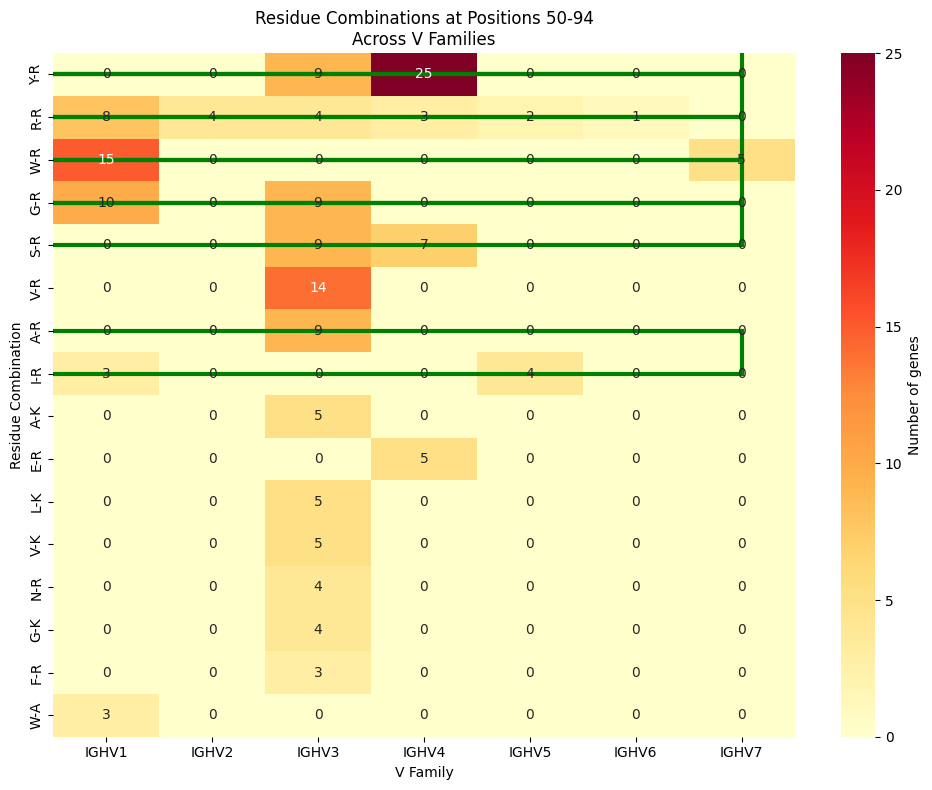

In [17]:
import pandas as pd
import numpy as np
from scipy.stats import fisher_exact
from itertools import combinations
import seaborn as sns
import matplotlib.pyplot as plt

class DirectConvergenceAnalyzer:
    def __init__(self, codons_df):
        """
        Parameters:
        -----------
        codons_df : pd.DataFrame
            DataFrame with columns: site, codon, v_gene, v_family, amino_acid
        """
        self.codons_df = codons_df.copy()
        self.codons_df['site'] = self.codons_df['site'].astype(str)
        
    def get_residue_combinations(self, positions):
        """
        For each gene, get the combination of residues at specified positions
        
        Returns DataFrame: v_gene, v_family, pos1_residue, pos2_residue, ..., combo
        """
        positions = [str(p) for p in positions]
        
        # Get data for these positions
        position_data = self.codons_df[self.codons_df['site'].isin(positions)]
        
        # Pivot to get one row per gene
        pivot = position_data.pivot_table(
            index=['v_gene', 'v_family'],
            columns='site',
            values='amino_acid',
            aggfunc='first'
        ).reset_index()
        
        # Create a combination string
        combo_cols = [str(p) for p in positions if str(p) in pivot.columns]
        pivot['combo'] = pivot[combo_cols].apply(
            lambda row: '-'.join([str(x) if pd.notna(x) else 'X' for x in row]),
            axis=1
        )
        
        return pivot
    
    def find_convergent_combinations(self, positions, min_families=2, min_genes_per_combo=2):
        """
        Find residue combinations that appear in multiple families
        
        Parameters:
        -----------
        positions : list
            Positions to analyze together (e.g., [64, 71])
        min_families : int
            Minimum number of families a combo must appear in
        min_genes_per_combo : int
            Minimum number of genes with this combo per family
        
        Returns:
        --------
        DataFrame with convergent combinations
        """
        positions = [str(p) for p in positions]
        
        # Get all combinations
        combo_df = self.get_residue_combinations(positions)
        
        # Count combinations by family
        combo_counts = combo_df.groupby(['combo', 'v_family']).size().reset_index(name='n_genes')
        
        # Filter to combos that appear in enough genes per family
        combo_counts = combo_counts[combo_counts['n_genes'] >= min_genes_per_combo]
        
        # Count how many families each combo appears in
        combo_family_counts = combo_counts.groupby('combo').agg({
            'v_family': lambda x: list(x),
            'n_genes': 'sum'
        }).reset_index()
        
        combo_family_counts['n_families'] = combo_family_counts['v_family'].apply(len)
        
        # Filter to convergent combos
        convergent = combo_family_counts[
            combo_family_counts['n_families'] >= min_families
        ].sort_values('n_families', ascending=False)
        
        convergent.columns = ['combo', 'families', 'total_genes', 'n_families']
        
        return convergent
    
    def test_pairwise_convergence(self, entrenched_positions, min_families=2):
        """
        Test all pairs of entrenched positions for convergent evolution
        
        Returns:
        --------
        DataFrame with results for each pair
        """
        entrenched_positions = [str(p) for p in entrenched_positions]
        
        results = []
        
        for pos1, pos2 in combinations(entrenched_positions, 2):
            print(f"\nAnalyzing {pos1}-{pos2}...")
            
            convergent = self.find_convergent_combinations(
                [pos1, pos2], 
                min_families=min_families,
                min_genes_per_combo=1  # At least 1 gene per family
            )
            
            if len(convergent) > 0:
                print(f"  Found {len(convergent)} convergent combinations")
                
                for idx, row in convergent.iterrows():
                    print(f"    {row['combo']}: appears in {row['n_families']} families "
                          f"({', '.join(row['families'])})")
                    
                    results.append({
                        'pos1': pos1,
                        'pos2': pos2,
                        'combo': row['combo'],
                        'n_families': row['n_families'],
                        'families': ', '.join(row['families']),
                        'total_genes': row['total_genes']
                    })
            else:
                print(f"  No convergent combinations found")
        
        return pd.DataFrame(results) if results else None
    
    def test_multi_position_convergence(self, positions, min_families=2):
        """
        Test for convergence across multiple positions simultaneously
        
        For example, if positions [64, 71, 73] show the same combo in multiple families
        """
        positions = [str(p) for p in positions]
        
        print(f"\nAnalyzing {len(positions)}-way combinations: {', '.join(positions)}")
        
        convergent = self.find_convergent_combinations(
            positions,
            min_families=min_families,
            min_genes_per_combo=1
        )
        
        if len(convergent) > 0:
            print(f"\nFound {len(convergent)} convergent {len(positions)}-way combinations:")
            for idx, row in convergent.iterrows():
                print(f"  {row['combo']}:")
                print(f"    Appears in {row['n_families']} families: {', '.join(row['families'])}")
                print(f"    Total genes: {row['total_genes']}")
        
        return convergent
    
    def visualize_combination_frequencies(self, positions):
        """
        Create a heatmap showing which combinations appear in which families
        """
        positions = [str(p) for p in positions]
        
        # Get combinations
        combo_df = self.get_residue_combinations(positions)
        
        # Count by family and combo
        freq_table = pd.crosstab(combo_df['combo'], combo_df['v_family'])
        
        # Sort by total frequency
        freq_table['total'] = freq_table.sum(axis=1)
        freq_table = freq_table.sort_values('total', ascending=False).drop('total', axis=1)
        
        # Only show combos that appear in multiple families or are common
        multi_family = (freq_table > 0).sum(axis=1) >= 2
        common = freq_table.sum(axis=1) >= 3
        freq_table = freq_table[multi_family | common]
        
        if len(freq_table) == 0:
            print("No combinations appear in multiple families")
            return None
        
        # Plot
        fig, ax = plt.subplots(figsize=(10, max(6, len(freq_table)/2)))
        
        sns.heatmap(freq_table, annot=True, fmt='d', cmap='YlOrRd', 
                   cbar_kws={'label': 'Number of genes'},
                   ax=ax)
        
        ax.set_title(f'Residue Combinations at Positions {"-".join(positions)}\nAcross V Families')
        ax.set_xlabel('V Family')
        ax.set_ylabel('Residue Combination')
        
        # Highlight convergent combos (appear in 2+ families)
        convergent_combos = freq_table[(freq_table > 0).sum(axis=1) >= 2].index
        
        if len(convergent_combos) > 0:
            for i, combo in enumerate(freq_table.index):
                if combo in convergent_combos:
                    ax.add_patch(plt.Rectangle((-0.5, i-0.5), freq_table.shape[1], 1,
                                              fill=False, edgecolor='green', linewidth=3))
        
        plt.tight_layout()
        return fig
    
    def detailed_convergence_report(self, pos1, pos2):
        """
        Detailed report for a specific position pair showing which genes
        have which residue combinations in which families
        """
        positions = [str(pos1), str(pos2)]
        combo_df = self.get_residue_combinations(positions)
        
        print(f"\n{'='*70}")
        print(f"DETAILED CONVERGENCE REPORT: {pos1}-{pos2}")
        print(f"{'='*70}")
        
        # Group by family and combo
        for family in sorted(combo_df['v_family'].unique()):
            family_data = combo_df[combo_df['v_family'] == family]
            
            print(f"\n{family}:")
            combo_counts = family_data['combo'].value_counts()
            
            for combo, count in combo_counts.items():
                genes = family_data[family_data['combo'] == combo]['v_gene'].tolist()
                print(f"  {combo}: {count} genes")
                print(f"    Genes: {', '.join(genes)}")
        
        # Identify convergent combos
        print(f"\n{'='*70}")
        print("CONVERGENT COMBINATIONS:")
        print(f"{'='*70}")
        
        convergent = self.find_convergent_combinations(positions, min_families=2, min_genes_per_combo=1)
        
        if len(convergent) > 0:
            for idx, row in convergent.iterrows():
                print(f"\n{row['combo']}:")
                print(f"  Appears in {row['n_families']} families: {', '.join(row['families'])}")
                print(f"  Total genes: {row['total_genes']}")
                
                # Show which specific genes in each family
                for family in row['families']:
                    family_genes = combo_df[
                        (combo_df['v_family'] == family) & 
                        (combo_df['combo'] == row['combo'])
                    ]['v_gene'].tolist()
                    print(f"    {family}: {', '.join(family_genes)}")
        else:
            print("No combinations appear in multiple families")
    
    def create_phylogenetic_visualization(self, positions):
        """
        Create a visualization showing which families share which combinations
        Helps visualize if convergence is independent of phylogeny
        """
        positions = [str(p) for p in positions]
        combo_df = self.get_residue_combinations(positions)
        
        # Get convergent combos
        convergent = self.find_convergent_combinations(positions, min_families=2)
        
        if len(convergent) == 0:
            print("No convergent combinations to visualize")
            return None
        
        # Create a presence/absence matrix
        combo_by_family = pd.crosstab(
            combo_df['v_family'], 
            combo_df['combo']
        )
        combo_by_family = (combo_by_family > 0).astype(int)
        
        # Only show convergent combos
        convergent_combos = convergent['combo'].tolist()
        combo_by_family = combo_by_family[
            [c for c in convergent_combos if c in combo_by_family.columns]
        ]
        
        if len(combo_by_family.columns) == 0:
            return None
        
        # Plot
        fig, ax = plt.subplots(figsize=(max(8, len(combo_by_family.columns)), 
                                       max(6, len(combo_by_family))))
        
        sns.heatmap(combo_by_family, annot=True, fmt='d', cmap='RdYlGn',
                   cbar=False, linewidths=1, linecolor='black', ax=ax)
        
        ax.set_title(f'Convergent Evolution: Positions {"-".join(positions)}\n' + 
                    'Green = combination present in family')
        ax.set_xlabel('Residue Combination')
        ax.set_ylabel('V Gene Family')
        
        plt.tight_layout()
        return fig


# Usage:
if __name__ == "__main__":
    # Initialize
    analyzer = DirectConvergenceAnalyzer(codons_df)
    
    # Your entrenched positions
    entrenched_positions = ["33", "35", "50", "52", "94"]
    
    print("="*70)
    print("DIRECT CONVERGENCE ANALYSIS")
    print("="*70)
    
    # Test all pairwise combinations
    print("\n1. Testing pairwise convergence...")
    pairwise_convergence = analyzer.test_pairwise_convergence(
        entrenched_positions, 
        min_families=2
    )
    
    if pairwise_convergence is not None:
        print("\n" + "="*70)
        print("SUMMARY: PAIRWISE CONVERGENCE")
        print("="*70)
        print(pairwise_convergence.to_string(index=False))
        
        # Visualize the most convergent pair
        top_pair = pairwise_convergence.nlargest(1, 'n_families').iloc[0]
        print(f"\n\nMost convergent pair: {top_pair['pos1']}-{top_pair['pos2']}")
        
        fig = analyzer.visualize_combination_frequencies([top_pair['pos1'], top_pair['pos2']])
        if fig:
            plt.savefig(f"convergence_{top_pair['pos1']}_{top_pair['pos2']}.png", 
                       dpi=300, bbox_inches='tight')
        
        # Detailed report
        analyzer.detailed_convergence_report(top_pair['pos1'], top_pair['pos2'])
    
    # Test 3-way combinations (if you suspect multi-position epistasis)
    print("\n\n2. Testing 3-way convergence...")
    for pos_combo in combinations(entrenched_positions[:4], 3):  # Test a few 3-way combos
        convergent_3way = analyzer.test_multi_position_convergence(
            list(pos_combo), 
            min_families=2
        )
    
    # Visualize all convergent patterns
    print("\n\n3. Visualizing all pairwise patterns...")
    for pos1, pos2 in combinations(entrenched_positions[:4], 2):
        fig = analyzer.visualize_combination_frequencies([pos1, pos2])
        if fig:
            plt.savefig(f"freq_heatmap_{pos1}_{pos2}.png", dpi=300, bbox_inches='tight')
            plt.close()
    
    plt.show()

Focusing on families: IGHV1, IGHV3, IGHV4
Total genes: 166
  IGHV1: 41 genes
  IGHV3: 85 genes
  IGHV4: 40 genes

GENOME-WIDE CONVERGENCE ANALYSIS
Families: IGHV1, IGHV3, IGHV4

Scanning all 102 positions
Total possible pairs: 5151



  Found 7052 convergent combinations across 4039 position pairs


Total convergent combinations found: 7052

TOP 20 CONVERGENT COMBINATIONS
pos1 pos2 combo  n_families            families  total_genes
   1    2   Q-V           3 IGHV1, IGHV3, IGHV4           83
   1    3   Q-Q           3 IGHV1, IGHV3, IGHV4           96
   1    4   Q-L           3 IGHV1, IGHV3, IGHV4           96
   1    7   Q-S           3 IGHV1, IGHV3, IGHV4           95
   1    8   Q-G           3 IGHV1, IGHV3, IGHV4           96
   1   13   Q-K           3 IGHV1, IGHV3, IGHV4           83
   1   14   Q-P           3 IGHV1, IGHV3, IGHV4           94
   1   22   Q-C           3 IGHV1, IGHV3, IGHV4           96
   1   25   Q-S           3 IGHV1, IGHV3, IGHV4           95
   1   26   Q-G           3 IGHV1, IGHV3, IGHV4           96
   1   29   Q-F           3 IGHV1, IGHV3, IGHV4           56
   1   30   Q-S           3 IGHV1, IGHV3, IGHV4           72
   1   31   Q-S           3 IGHV1, IGHV3, IGHV4           83
   1 



Detailed analysis of top entrenched pair:

DETAILED ANALYSIS: 64-66

IGHV1 (41 genes):
  Q-R: 40 gene(s)
  Q-W: 1 gene(s)
    IGHV1-2*04

IGHV3 (85 genes):
  K-R: 82 gene(s)
  M-R: 2 gene(s)
    IGHV3-47*01, IGHV3-47*02
  K-Q: 1 gene(s)
    IGHV3-35*02

IGHV4 (40 genes):
  K-R: 39 gene(s)
  K-L: 1 gene(s)
    IGHV4-31*01

CONVERGENT COMBINATIONS:

✓ K-R - CONVERGENT!
  Appears in 2/3 families: IGHV3, IGHV4
  Total genes: 121
    IGHV3: IGHV3-11*01, IGHV3-11*04, IGHV3-11*05, IGHV3-11*06, IGHV3-13*01, IGHV3-13*04, IGHV3-13*05, IGHV3-13*06, IGHV3-15*01, IGHV3-15*07, IGHV3-16*02, IGHV3-16*03, IGHV3-16*04, IGHV3-19*01, IGHV3-20*01, IGHV3-20*02, IGHV3-20*04, IGHV3-21*01, IGHV3-21*03, IGHV3-21*05, IGHV3-21*06, IGHV3-21*07, IGHV3-23*01, IGHV3-23*03, IGHV3-23*04, IGHV3-25*04, IGHV3-30*01, IGHV3-30*02, IGHV3-30*03, IGHV3-30*04, IGHV3-30*18, IGHV3-30*20, IGHV3-30*i02, IGHV3-30-3*01, IGHV3-33*01, IGHV3-33*06, IGHV3-33*08, IGHV3-35*01, IGHV3-38*01, IGHV3-38*02, IGHV3-38*03, IGHV3-38-3*01, IGHV3-4



Results saved!


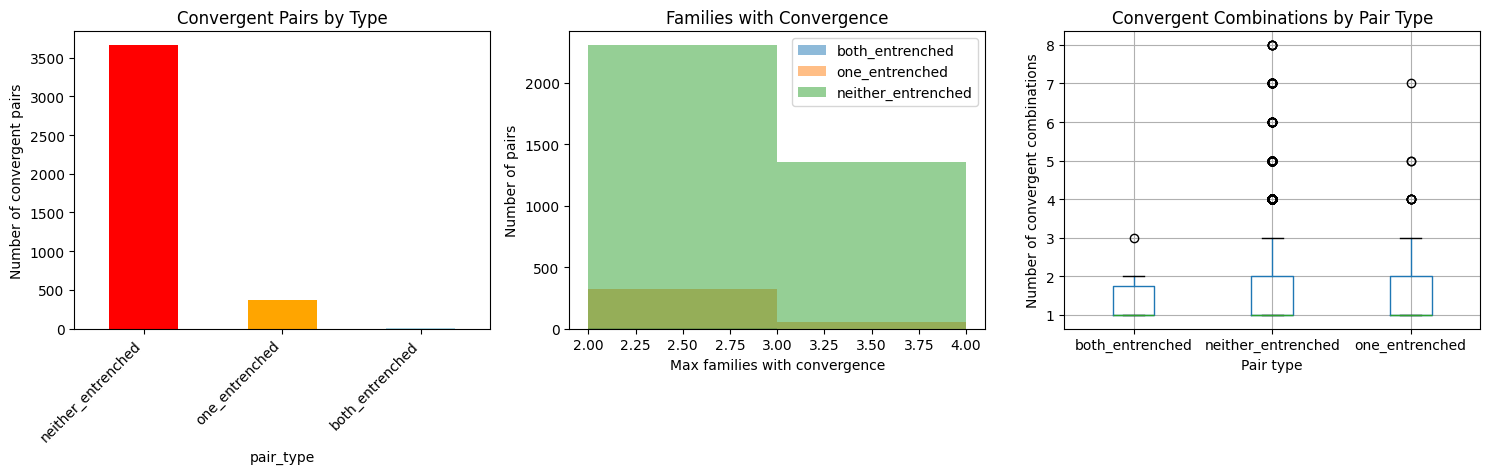

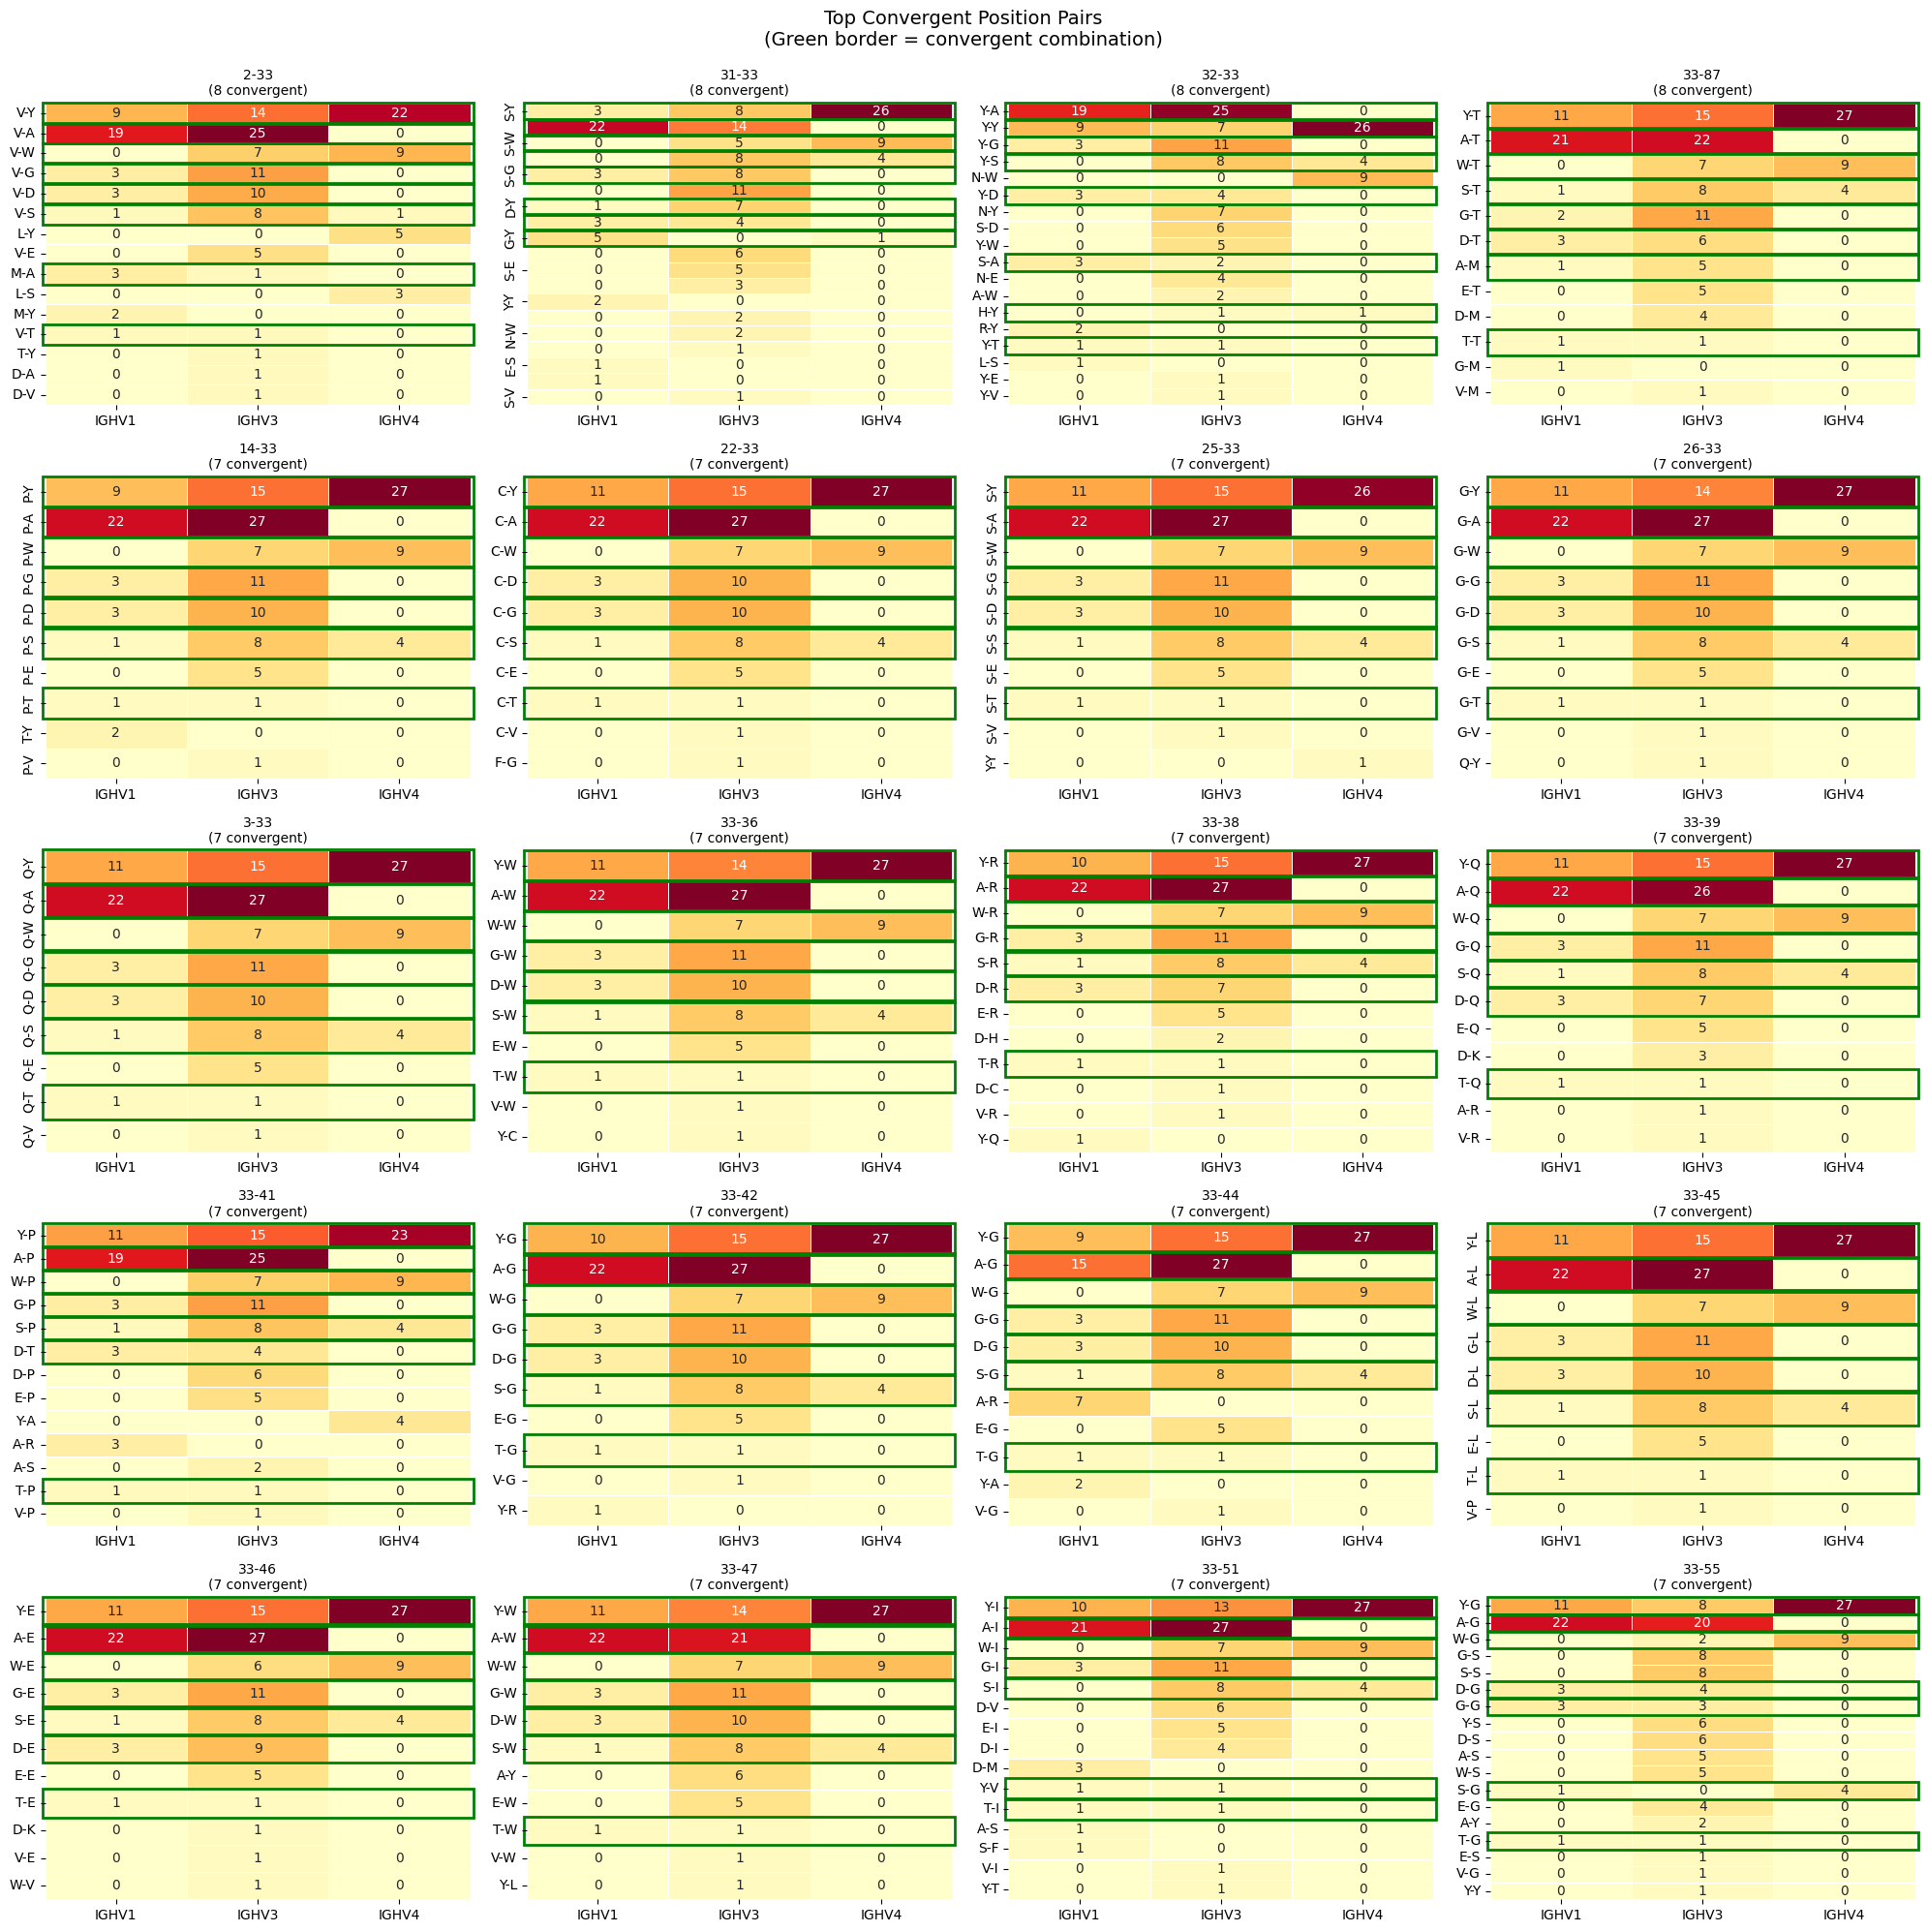

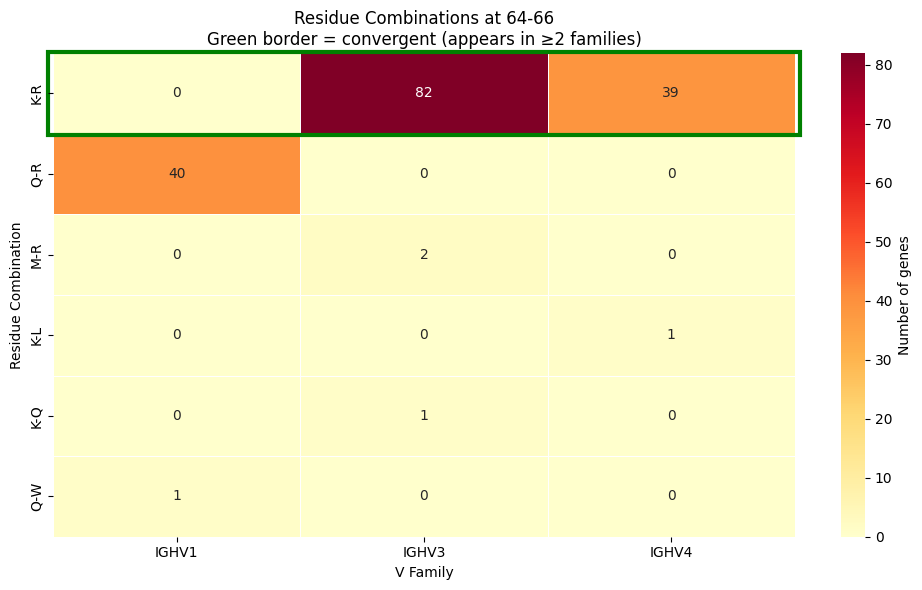

In [18]:
import pandas as pd
import numpy as np
from scipy.stats import fisher_exact, mannwhitneyu
from itertools import combinations
import seaborn as sns
import matplotlib.pyplot as plt

class FocusedConvergenceAnalyzer:
    def __init__(self, codons_df, focus_families=['IGHV1', 'IGHV3', 'IGHV4']):
        """
        Parameters:
        -----------
        codons_df : pd.DataFrame
            DataFrame with columns: site, codon, v_gene, v_family, amino_acid
        focus_families : list
            List of V families to focus on
        """
        # Filter to focus families only
        self.codons_df = codons_df[codons_df['v_family'].isin(focus_families)].copy()
        self.codons_df['site'] = self.codons_df['site'].astype(str)
        self.focus_families = focus_families
        
        print(f"Focusing on families: {', '.join(focus_families)}")
        print(f"Total genes: {self.codons_df['v_gene'].nunique()}")
        for family in focus_families:
            n_genes = self.codons_df[self.codons_df['v_family'] == family]['v_gene'].nunique()
            print(f"  {family}: {n_genes} genes")
        
    def _sort_key(self, site):
        """Sort sites naturally"""
        import re
        match = re.match(r'(\d+)([A-Z]?)', str(site))
        if match:
            num, letter = match.groups()
            return (int(num), letter if letter else '')
        return (float('inf'), str(site))
    
    def get_all_positions(self):
        """Get all available positions"""
        return sorted(self.codons_df['site'].unique(), key=self._sort_key)
    
    def get_residue_combinations(self, positions):
        """
        For each gene, get the combination of residues at specified positions
        """
        positions = [str(p) for p in positions]
        
        # Get data for these positions
        position_data = self.codons_df[self.codons_df['site'].isin(positions)]
        
        # Pivot to get one row per gene
        pivot = position_data.pivot_table(
            index=['v_gene', 'v_family'],
            columns='site',
            values='amino_acid',
            aggfunc='first'
        ).reset_index()
        
        # Create a combination string
        combo_cols = [str(p) for p in positions if str(p) in pivot.columns]
        if not combo_cols:
            return None
            
        pivot['combo'] = pivot[combo_cols].apply(
            lambda row: '-'.join([str(x) if pd.notna(x) else 'X' for x in row]),
            axis=1
        )
        
        # Remove rows with missing data
        pivot = pivot[~pivot['combo'].str.contains('X')]
        
        return pivot
    
    def find_convergent_combinations(self, positions, min_families=2):
        """
        Find residue combinations that appear in multiple families
        
        For focused analysis, we want combinations that appear in at least
        min_families of our focus families
        """
        positions = [str(p) for p in positions]
        
        # Get all combinations
        combo_df = self.get_residue_combinations(positions)
        
        if combo_df is None or len(combo_df) == 0:
            return None
        
        # Count combinations by family
        combo_counts = combo_df.groupby(['combo', 'v_family']).size().reset_index(name='n_genes')
        
        # Count how many families each combo appears in
        combo_family_counts = combo_counts.groupby('combo').agg({
            'v_family': lambda x: list(x),
            'n_genes': 'sum'
        }).reset_index()
        
        combo_family_counts['n_families'] = combo_family_counts['v_family'].apply(len)
        
        # Filter to convergent combos
        convergent = combo_family_counts[
            combo_family_counts['n_families'] >= min_families
        ].sort_values('n_families', ascending=False)
        
        if len(convergent) == 0:
            return None
        
        convergent.columns = ['combo', 'families', 'total_genes', 'n_families']
        
        return convergent
    
    def scan_all_pairwise_convergence(self, min_families=2):
        """
        Scan ALL pairs of positions for convergent evolution
        
        Returns:
        --------
        DataFrame with convergence statistics for each pair
        """
        all_positions = self.get_all_positions()
        
        print(f"\nScanning all {len(all_positions)} positions")
        print(f"Total possible pairs: {len(all_positions) * (len(all_positions)-1) // 2}")
        
        # Generate all pairs
        all_pairs = list(combinations(all_positions, 2))
        
        results = []
        
        for i, (pos1, pos2) in enumerate(all_pairs):
            if i % 500 == 0:
                print(f"  Processed {i}/{len(all_pairs)} pairs... (found {len(results)} convergent)", end='\r')
            
            convergent = self.find_convergent_combinations(
                [pos1, pos2], 
                min_families=min_families
            )
            
            if convergent is not None and len(convergent) > 0:
                # Store info about all convergent combos for this pair
                for _, row in convergent.iterrows():
                    results.append({
                        'pos1': pos1,
                        'pos2': pos2,
                        'combo': row['combo'],
                        'n_families': row['n_families'],
                        'families': ', '.join(sorted(row['families'])),
                        'total_genes': row['total_genes']
                    })
        
        print(f"\n  Found {len(results)} convergent combinations across {len(set((r['pos1'], r['pos2']) for r in results))} position pairs")
        
        return pd.DataFrame(results) if results else None
    
    def detailed_pair_analysis(self, pos1, pos2):
        """
        Detailed analysis of a specific position pair showing convergence
        """
        positions = [str(pos1), str(pos2)]
        combo_df = self.get_residue_combinations(positions)
        
        if combo_df is None:
            print(f"No data for {pos1}-{pos2}")
            return
        
        print(f"\n{'='*70}")
        print(f"DETAILED ANALYSIS: {pos1}-{pos2}")
        print(f"{'='*70}")
        
        # Show distribution by family
        for family in self.focus_families:
            family_data = combo_df[combo_df['v_family'] == family]
            
            if len(family_data) == 0:
                print(f"\n{family}: No data")
                continue
            
            print(f"\n{family} ({len(family_data)} genes):")
            combo_counts = family_data['combo'].value_counts()
            
            for combo, count in combo_counts.items():
                genes = family_data[family_data['combo'] == combo]['v_gene'].tolist()
                print(f"  {combo}: {count} gene(s)")
                if count <= 5:  # Only show gene names if not too many
                    print(f"    {', '.join(genes)}")
        
        # Identify convergent combos
        convergent = self.find_convergent_combinations(positions, min_families=2)
        
        if convergent is not None and len(convergent) > 0:
            print(f"\n{'='*70}")
            print("CONVERGENT COMBINATIONS:")
            print(f"{'='*70}")
            
            for idx, row in convergent.iterrows():
                print(f"\n✓ {row['combo']} - CONVERGENT!")
                print(f"  Appears in {row['n_families']}/3 families: {', '.join(sorted(row['families']))}")
                print(f"  Total genes: {row['total_genes']}")
                
                # Show genes in each family
                for family in row['families']:
                    family_genes = combo_df[
                        (combo_df['v_family'] == family) & 
                        (combo_df['combo'] == row['combo'])
                    ]['v_gene'].tolist()
                    print(f"    {family}: {', '.join(family_genes)}")
        else:
            print(f"\nNo combinations appear in ≥2 families")
        
        # Create visualization
        fig, ax = plt.subplots(figsize=(10, 6))
        
        # Create frequency table
        freq_table = pd.crosstab(combo_df['combo'], combo_df['v_family'])
        
        # Sort by total frequency
        freq_table['total'] = freq_table.sum(axis=1)
        freq_table = freq_table.sort_values('total', ascending=False).drop('total', axis=1)
        
        # Plot
        sns.heatmap(freq_table, annot=True, fmt='d', cmap='YlOrRd',
                   cbar_kws={'label': 'Number of genes'},
                   ax=ax, linewidths=0.5)
        
        # Highlight convergent combos
        if convergent is not None:
            convergent_combos = convergent['combo'].tolist()
            for i, combo in enumerate(freq_table.index):
                if combo in convergent_combos:
                    ax.add_patch(plt.Rectangle((-0.02, i-0.02), 
                                              freq_table.shape[1]+0.04, 1.04,
                                              fill=False, edgecolor='green', 
                                              linewidth=3, clip_on=False))
        
        ax.set_title(f'Residue Combinations at {pos1}-{pos2}\n' + 
                    'Green border = convergent (appears in ≥2 families)')
        ax.set_xlabel('V Family')
        ax.set_ylabel('Residue Combination')
        
        plt.tight_layout()
        return fig
    
    def visualize_top_convergent_pairs(self, convergence_results, top_n=20):
        """
        Create a grid of heatmaps for the top convergent position pairs
        """
        # Get unique pairs ranked by number of convergent combos
        pair_summary = convergence_results.groupby(['pos1', 'pos2']).agg({
            'combo': 'count',
            'n_families': 'max'
        }).reset_index()
        pair_summary.columns = ['pos1', 'pos2', 'n_convergent_combos', 'max_families']
        pair_summary = pair_summary.sort_values(
            ['max_families', 'n_convergent_combos'], 
            ascending=False
        ).head(top_n)
        
        # Create subplots
        n_pairs = len(pair_summary)
        n_cols = 4
        n_rows = (n_pairs + n_cols - 1) // n_cols
        
        fig, axes = plt.subplots(n_rows, n_cols, figsize=(5*n_cols, 4*n_rows))
        axes = axes.flatten() if n_pairs > 1 else [axes]
        
        for idx, (_, row) in enumerate(pair_summary.iterrows()):
            if idx >= len(axes):
                break
            
            ax = axes[idx]
            
            # Get data for this pair
            combo_df = self.get_residue_combinations([row['pos1'], row['pos2']])
            
            if combo_df is None:
                ax.axis('off')
                continue
            
            # Create frequency table
            freq_table = pd.crosstab(combo_df['combo'], combo_df['v_family'])
            
            # Sort by total
            freq_table['total'] = freq_table.sum(axis=1)
            freq_table = freq_table.sort_values('total', ascending=False).drop('total', axis=1)
            
            # Plot
            sns.heatmap(freq_table, annot=True, fmt='d', cmap='YlOrRd',
                       cbar=False, ax=ax, linewidths=0.5)
            
            # Highlight convergent
            convergent = self.find_convergent_combinations([row['pos1'], row['pos2']], min_families=2)
            if convergent is not None:
                convergent_combos = convergent['combo'].tolist()
                for i, combo in enumerate(freq_table.index):
                    if combo in convergent_combos:
                        ax.add_patch(plt.Rectangle((-0.02, i-0.02), 
                                                  freq_table.shape[1]+0.04, 1.04,
                                                  fill=False, edgecolor='green', 
                                                  linewidth=2, clip_on=False))
            
            ax.set_title(f'{row["pos1"]}-{row["pos2"]}\n({row["n_convergent_combos"]} convergent)',
                        fontsize=10)
            ax.set_xlabel('')
            ax.set_ylabel('')
        
        # Hide unused subplots
        for idx in range(len(pair_summary), len(axes)):
            axes[idx].axis('off')
        
        plt.suptitle('Top Convergent Position Pairs\n(Green border = convergent combination)',
                    fontsize=14, y=0.995)
        plt.tight_layout()
        
        return fig
    
    def compare_entrenched_vs_all(self, convergence_results, entrenched_positions):
        """
        Compare convergence for entrenched sites vs all sites
        """
        entrenched_positions = [str(p) for p in entrenched_positions]
        
        # Get unique position pairs
        pair_summary = convergence_results.groupby(['pos1', 'pos2']).agg({
            'n_families': 'max',
            'combo': 'count'
        }).reset_index()
        pair_summary.columns = ['pos1', 'pos2', 'max_families', 'n_convergent_combos']
        
        # Classify pairs
        def classify_pair(row):
            pos1, pos2 = str(row['pos1']), str(row['pos2'])
            if pos1 in entrenched_positions and pos2 in entrenched_positions:
                return 'both_entrenched'
            elif pos1 in entrenched_positions or pos2 in entrenched_positions:
                return 'one_entrenched'
            else:
                return 'neither_entrenched'
        
        pair_summary['pair_type'] = pair_summary.apply(classify_pair, axis=1)
        
        print("\n" + "="*70)
        print("CONVERGENCE: ENTRENCHED VS OTHER SITES")
        print("="*70)
        
        summary = pair_summary.groupby('pair_type').agg({
            'max_families': ['count', 'mean', 'median'],
            'n_convergent_combos': ['mean', 'median', 'sum']
        }).reset_index()
        
        print(summary)
        
        # Statistical tests
        both = pair_summary[pair_summary['pair_type'] == 'both_entrenched']
        neither = pair_summary[pair_summary['pair_type'] == 'neither_entrenched']
        
        if len(both) > 0 and len(neither) > 0:
            # Test max_families
            stat, p_val = mannwhitneyu(both['max_families'], neither['max_families'],
                                      alternative='greater')
            print(f"\nMann-Whitney U test (max_families):")
            print(f"  Entrenched pairs vs other pairs")
            print(f"  p-value: {p_val:.3e}")
            if p_val < 0.05:
                print(f"  ✓ Entrenched sites show MORE convergence!")
            
            # Test n_convergent_combos
            stat, p_val = mannwhitneyu(both['n_convergent_combos'], 
                                      neither['n_convergent_combos'],
                                      alternative='greater')
            print(f"\nMann-Whitney U test (n_convergent_combos):")
            print(f"  Entrenched pairs vs other pairs")
            print(f"  p-value: {p_val:.3e}")
            if p_val < 0.05:
                print(f"  ✓ Entrenched sites show MORE convergent combinations!")
        
        # Visualization
        fig, axes = plt.subplots(1, 3, figsize=(15, 5))
        
        # Plot 1: Count of pairs
        ax = axes[0]
        counts = pair_summary['pair_type'].value_counts()
        counts.plot(kind='bar', ax=ax, color=['red', 'orange', 'lightblue'])
        ax.set_ylabel('Number of convergent pairs')
        ax.set_title('Convergent Pairs by Type')
        ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right')
        
        # Plot 2: Max families distribution
        ax = axes[1]
        for pair_type in ['both_entrenched', 'one_entrenched', 'neither_entrenched']:
            data = pair_summary[pair_summary['pair_type'] == pair_type]['max_families']
            if len(data) > 0:
                ax.hist(data, alpha=0.5, label=pair_type, bins=range(2, 5))
        ax.set_xlabel('Max families with convergence')
        ax.set_ylabel('Number of pairs')
        ax.legend()
        ax.set_title('Families with Convergence')
        
        # Plot 3: Convergent combos
        ax = axes[2]
        pair_summary.boxplot(column='n_convergent_combos', by='pair_type', ax=ax)
        ax.set_xlabel('Pair type')
        ax.set_ylabel('Number of convergent combinations')
        ax.set_title('Convergent Combinations by Pair Type')
        plt.suptitle('')
        
        plt.tight_layout()
        return fig, pair_summary


# Example usage:
if __name__ == "__main__":
    # Initialize with focus on IGHV1, IGHV3, IGHV4
    analyzer = FocusedConvergenceAnalyzer(
        codons_df, 
        focus_families=['IGHV1', 'IGHV3', 'IGHV4']
    )
    
    # Your entrenched positions
    entrenched_positions = ["64", "66", "71", "73", "76"]
    
    print("\n" + "="*70)
    print("GENOME-WIDE CONVERGENCE ANALYSIS")
    print("Families: IGHV1, IGHV3, IGHV4")
    print("="*70)
    
    # Scan ALL position pairs
    all_convergence = analyzer.scan_all_pairwise_convergence(min_families=2)
    
    if all_convergence is not None:
        print(f"\n\nTotal convergent combinations found: {len(all_convergence)}")
        
        # Show top results
        print("\n" + "="*70)
        print("TOP 20 CONVERGENT COMBINATIONS")
        print("="*70)
        top_20 = all_convergence.nlargest(20, 'n_families')
        print(top_20.to_string(index=False))
        
        # Analyze entrenched positions
        entrenched_pairs = all_convergence[
            (all_convergence['pos1'].isin(entrenched_positions)) &
            (all_convergence['pos2'].isin(entrenched_positions))
        ]
        
        print(f"\n\nConvergent combinations among entrenched sites: {len(entrenched_pairs)}")
        if len(entrenched_pairs) > 0:
            print(entrenched_pairs.to_string(index=False))
        
        # Compare entrenched vs all
        fig, pair_summary = analyzer.compare_entrenched_vs_all(
            all_convergence, entrenched_positions
        )
        plt.savefig('convergence_entrenched_vs_all.png', dpi=300, bbox_inches='tight')
        
        # Visualize top pairs
        fig = analyzer.visualize_top_convergent_pairs(all_convergence, top_n=20)
        plt.savefig('top_convergent_pairs_heatmaps.png', dpi=300, bbox_inches='tight')
        
        # Detailed analysis of specific interesting pairs
        if len(entrenched_pairs) > 0:
            # Pick top entrenched pair
            top_entrenched = entrenched_pairs.nlargest(1, 'n_families').iloc[0]
            print(f"\n\nDetailed analysis of top entrenched pair:")
            fig = analyzer.detailed_pair_analysis(top_entrenched['pos1'], 
                                                  top_entrenched['pos2'])
            plt.savefig(f'detailed_{top_entrenched["pos1"]}_{top_entrenched["pos2"]}.png',
                       dpi=300, bbox_inches='tight')
        
        # Save results
        all_convergence.to_csv('convergence_results_IGHV134.csv', index=False)
        pair_summary.to_csv('convergence_pairs_summary_IGHV134.csv', index=False)
        
        print("\n\nResults saved!")
        plt.show()